<a href="https://colab.research.google.com/github/lenmecc/miniature-enigma/blob/main/integrador_2_LFRG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROYECTO**



**OBJETIVOS:**


1. Desarrollar un análisis de Data Wrangling y preparación de los datos, incluyendo el respectivo análisis exploratorio univaridado, bivariado y multivariado.
2. Desarrollar un análisis de segmentación que incluya los algoritmos revisados en clase, y los métodos para elegir la k óptima.
3.	Realizar un análisis de perfilamiento efectivo y que le permita a PriceCo reconocer las características de cada segmento formado.


# **Acciones para la correción de las áreas detectadas**
***Usaremos la base de datos de Accidentes industriales llamada PS_2_S6.xlsx***

In [ ]:
import pandas as pd
df = pd.read_excel('Price-Co_sales.xlsx')
df.head()

,Invoice ID,City,Membership,Gender,Product line,Unit price_mxp,Quantity,Tax 15%,Total_mxp,Date,Payment,Rating
0,750-67-8428,Mexico DF,Nomal,Female,Health and beauty,1329.482,7,1395.9561,9306.374,2019-05-01 00:00:00,Ewallet,9.1
1,226-31-3081,Guadalajara,Plus,Female,Electronic accessories,271.984,5,203.9880,1359.920,2019-08-03 00:00:00,Cash,9.6
2,631-41-3108,Mexico DF,Plus,Male,Home and lifestyle,824.674,7,865.9077,5772.718,2019-03-03 00:00:00,Credit card,7.4
3,123-19-1176,Mexico DF,Nomal,Male,Health and beauty,1036.316,8,1243.5792,8290.528,1/27/2019,Ewallet,8.4
4,373-73-7910,Mexico DF,Plus,Male,Sports and travel,1536.318,7,1613.1339,10754.226,2019-08-02 00:00:00,Ewallet,5.3


In [ ]:
#Antes de comenzar, importemos algunas librerías necesarias
#Preescindamos de los warnings al correor nuestro código
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline


Comenzemos con la validación usando el Check list.

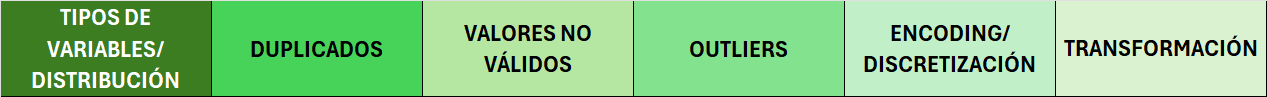



## **Tipos de Variables y Distribuciones**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Invoice ID      1000 non-null   object 
 1   City            1000 non-null   object 
 2   Membership      1000 non-null   object 
 3   Gender          1000 non-null   object 
 4   Product line    1000 non-null   object 
 5   Unit price_mxp  1000 non-null   float64
 6   Quantity        1000 non-null   int64  
 7   Tax 15%         1000 non-null   float64
 8   Total_mxp       1000 non-null   float64
 9   Date            1000 non-null   object 
 10  Payment         1000 non-null   object 
 11  Rating          1000 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 93.9+ KB


Comentario: Se identificó que algunas variables del conjunto de datos son categóricas. Por lo tanto, se procederá a cambiar su tipo de dato para las siguientes variables: City, Membership, Gender, Payment y Product line.

Posteriormente, se aplicará One-Hot Encoding a las variables categóricas que se consideren relevantes para mantener dentro del análisis.

In [ ]:
# Cambiando las variables a categóricas
categorical_columns = ['City', 'Membership', 'Gender',"Product line","Payment"]
df[categorical_columns] = df[categorical_columns].astype('category')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Invoice ID      1000 non-null   object  
 1   City            1000 non-null   category
 2   Membership      1000 non-null   category
 3   Gender          1000 non-null   category
 4   Product line    1000 non-null   category
 5   Unit price_mxp  1000 non-null   float64 
 6   Quantity        1000 non-null   int64   
 7   Tax 15%         1000 non-null   float64 
 8   Total_mxp       1000 non-null   float64 
 9   Date            1000 non-null   object  
 10  Payment         1000 non-null   category
 11  Rating          1000 non-null   float64 
dtypes: category(5), float64(4), int64(1), object(2)
memory usage: 60.4+ KB


## **Registros duplicados**

In [ ]:
# Descubriendo si registros duplicados
duplicated_rows = df[df.duplicated()]
num_duplicated_rows = df.duplicated().sum()

# Mostrando el resultado de la evaluación
print("Registros duplicados:")
print(num_duplicated_rows)

Registros duplicados:
0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Invoice ID      1000 non-null   object  
 1   City            1000 non-null   category
 2   Membership      1000 non-null   category
 3   Gender          1000 non-null   category
 4   Product line    1000 non-null   category
 5   Unit price_mxp  1000 non-null   float64 
 6   Quantity        1000 non-null   int64   
 7   Tax 15%         1000 non-null   float64 
 8   Total_mxp       1000 non-null   float64 
 9   Date            1000 non-null   object  
 10  Payment         1000 non-null   category
 11  Rating          1000 non-null   float64 
dtypes: category(5), float64(4), int64(1), object(2)
memory usage: 60.4+ KB


**Resumen del dataset:**

In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Invoice ID,1000,1000,849-09-3807,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,1000,3,Mexico DF,340,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Membership,1000,2,Nomal,501,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,1000,2,Female,501,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product line,1000,6,Fashion accessories,178,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Unit price_mxp,1000.0,NaN,NaN,NaN,990.963914,471.604385,179.424,585.175,983.094,1387.243,1779.288
Quantity,1000.0,NaN,NaN,NaN,5.51,2.923431,1.0,3.0,5.0,8.0,10.0
Tax 15%,1000.0,NaN,NaN,NaN,821.258305,625.251281,27.1539,316.388325,645.4992,1198.57635,2651.31
Total_mxp,1000.0,NaN,NaN,NaN,5475.055364,4168.341871,181.026,2109.2555,4303.328,7990.509,17675.4
Date,1000,89,2019-07-02 00:00:00,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observaciones:**

1. No se detectan valores nulos en el conjunto de datos.

2. Se identifican seis líneas de productos diferentes; la más consumida es "Fashion accessories".

3. El precio promedio por artículo es de $983.09, según la mediana.

4. La desviación estándar es de $471, lo que indica una alta variabilidad en los precios, lo cual es coherente al comparar los valores máximos y mínimos.

5. La cantidad promedio de artículos adquiridos por cliente es de 5 unidades, según la mediana.

6. El ticket promedio por cliente es de $4,303. En mi opinión, este valor parece elevado, por lo que se validará más adelante durante el análisis exploratorio de datos (EDA).

7. La mayoría de los clientes realizan sus pagos mediante E-Wallet

## **Proyección de las distribuciones de las variables numéricas y Box plots**

Cuartiles y RIQ:
- Q1 (25%): 585.175
- Mediana (Q2): 983.094
- Q3 (75%): 1387.2430000000002
- Rango Intercuartílico (RIQ): 802.0680000000002
- Límite inferior: -617.9270000000004
- Límite superior: 2590.3450000000003

Ejemplos de valores atípicos (primeros 10):
[]


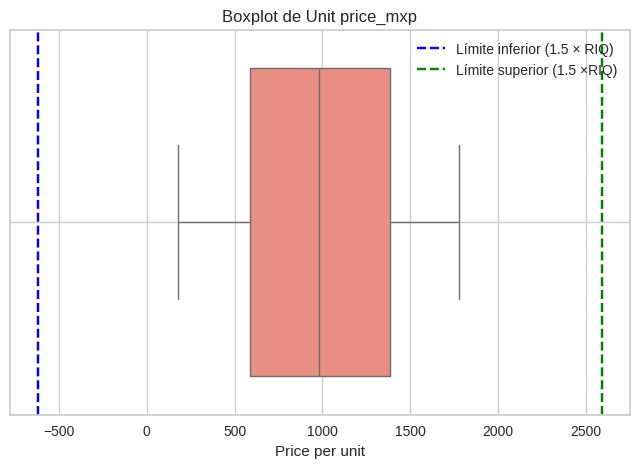

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns


# Seleccionar y limpiar la variable Noise atPlace
noise_data = df['Unit price_mxp'].dropna()

# Calcular cuartiles y RIQ
Q1 = np.percentile(noise_data, 25)
Q2 = np.percentile(noise_data, 50)  # Mediana
Q3 = np.percentile(noise_data, 75)
RIQ = Q3 - Q1

# Calcular límites según la regla 1.5 × RIQ
# Podemos cambiar el multiplicados, sustituyendo el 1.5 por 3
mult = 1.5
limite_inferior = Q1 - mult * RIQ
limite_superior = Q3 + mult * RIQ

# Identificar outliers
outliers = noise_data[(noise_data < limite_inferior) | (noise_data > limite_superior)]

# Mostrar resumen por consola
print("Cuartiles y RIQ:")
print(f"- Q1 (25%): {Q1}")
print(f"- Mediana (Q2): {Q2}")
print(f"- Q3 (75%): {Q3}")
print(f"- Rango Intercuartílico (RIQ): {RIQ}")
print(f"- Límite inferior: {limite_inferior}")
print(f"- Límite superior: {limite_superior}\n")

print("Ejemplos de valores atípicos (primeros 10):")
print(outliers.values[:10])

# Graficar boxplot y añadir líneas con los límites manuales
plt.figure(figsize=(8, 5))
sns.boxplot(x=noise_data, orient='h', color='salmon')

# Agregar líneas verticales para los límites calculados manualmente

plt.axvline(limite_inferior, color='blue', linestyle='--', label=f'Límite inferior ({mult} × RIQ)')
plt.axvline(limite_superior, color='green', linestyle='--', label=f'Límite superior ({mult} ×RIQ)')

plt.title('Boxplot de Unit price_mxp')
plt.xlabel('Price per unit')
plt.legend()
plt.grid(True)
plt.show()


### ***Análisis de distribuciones***

In [ ]:
# Mientras hacemos un análisis univariado de variables numéricas, queremos estudiar su tendencia central y dispersión.
# Generemos una función que nos ayudará a crear un diagrama de caja y un histograma para cualquier variable numérica de entrada.
# Esta función toma la columna numérica como entrada y devuelve los diagramas de caja y los histogramas para la variable.

def histogram_boxplot(data, feature, figsize=(12, 7), kde=True, bins=None, mult=1.5):
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,
        sharex=True,
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize)

    # Calcula percentiles y límites basados en el RIQ
    q1 = data[feature].quantile(0.25)
    q3 = data[feature].quantile(0.75)
    iqr = q3 - q1
    mult = 1.5
    lower_bound = q1 - mult * iqr
    upper_bound = q3 + mult * iqr

    # Boxplot
    sns.boxplot(data=data, x=feature, ax=ax_box2, showmeans=True, color="blue")

    # Histograma
    if bins:
        sns.histplot(data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="spring")
    else:
        sns.histplot(data=data, x=feature, kde=kde, ax=ax_hist2)

    # Líneas verticales para media, mediana y límites
    ax_hist2.axvline(data[feature].mean(), color="green", linestyle="--", label="Media")
    ax_hist2.axvline(data[feature].median(), color="black", linestyle="-", label="Mediana")
    ax_hist2.axvline(lower_bound, color='blue', linestyle='--', label=f'Límite inferior ({mult}×RIQ)')
    ax_hist2.axvline(upper_bound, color='red', linestyle='--', label=f'Límite superior ({mult}×RIQ)')

    ax_hist2.legend()
    plt.tight_layout()
    plt.show()

Diagrama para Unit price_mxp


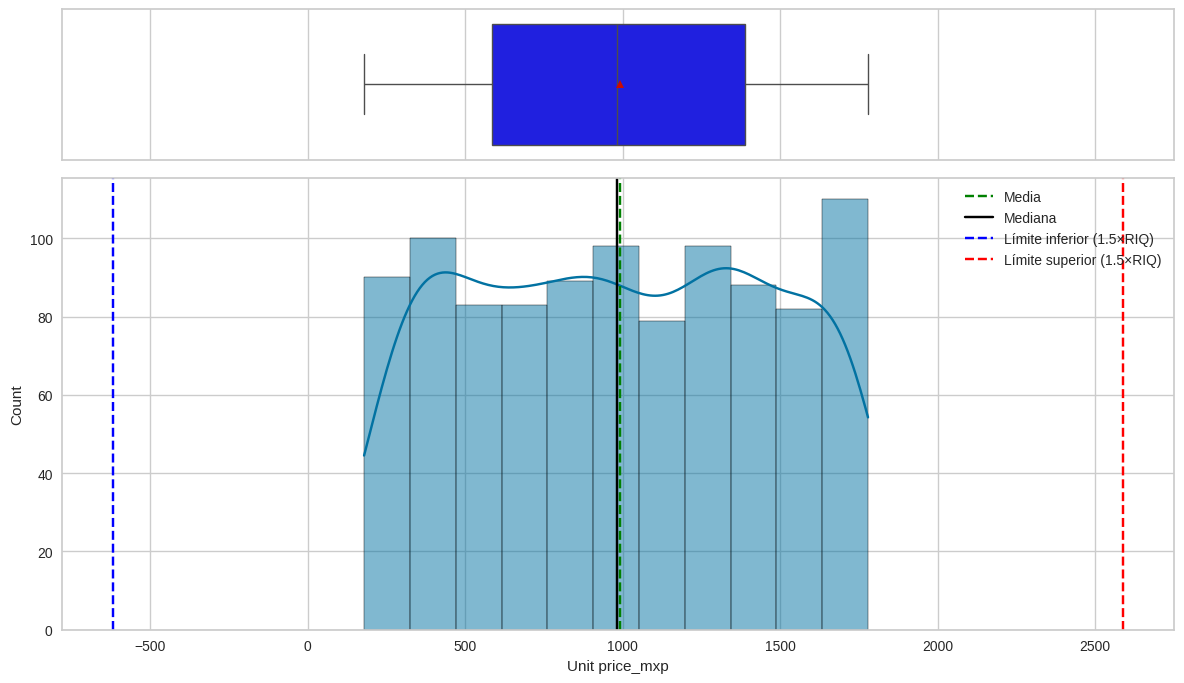

Diagrama para Quantity


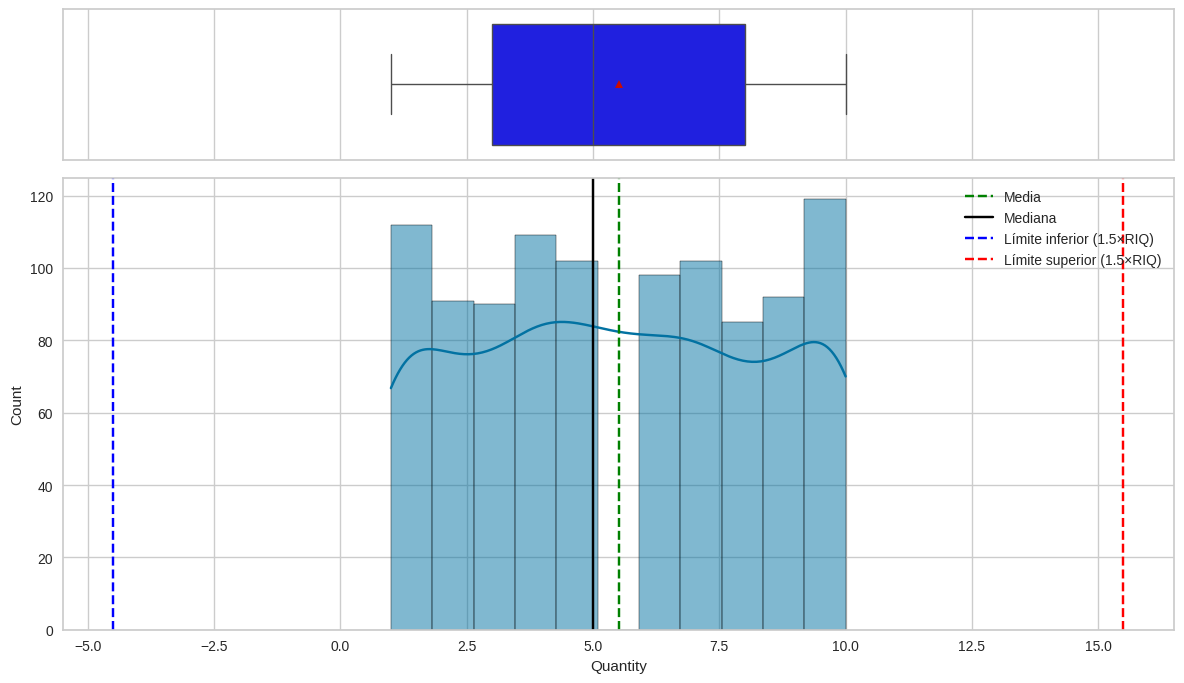

Diagrama para Tax 15%


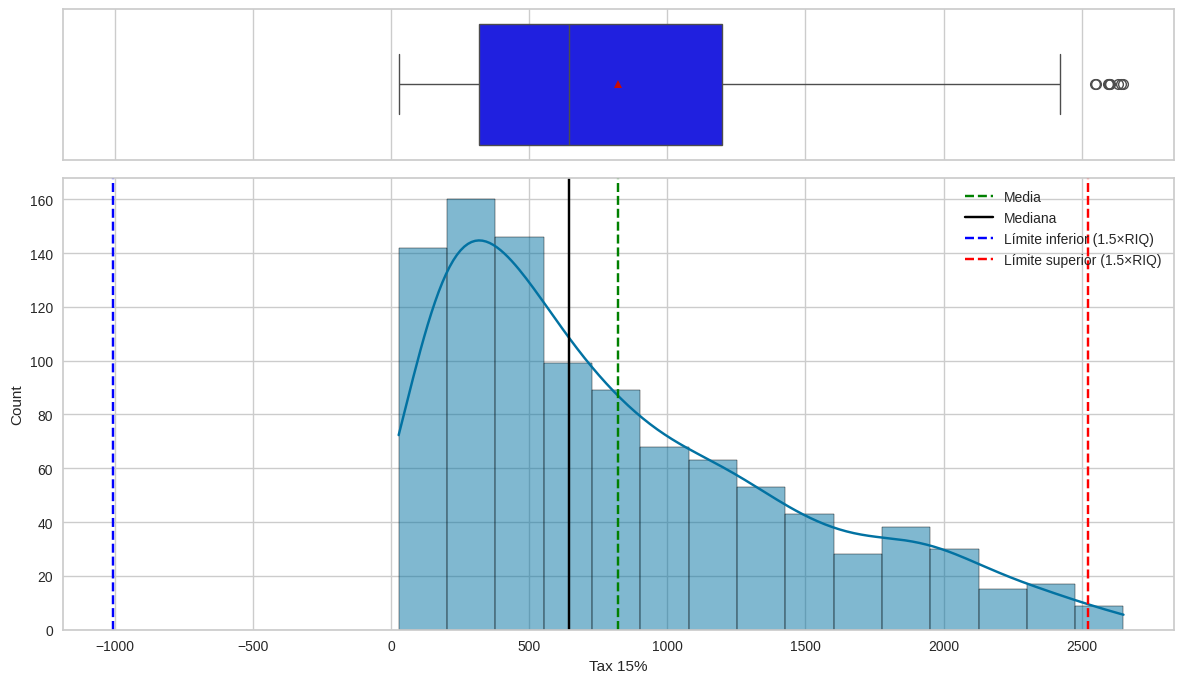

Diagrama para Total_mxp


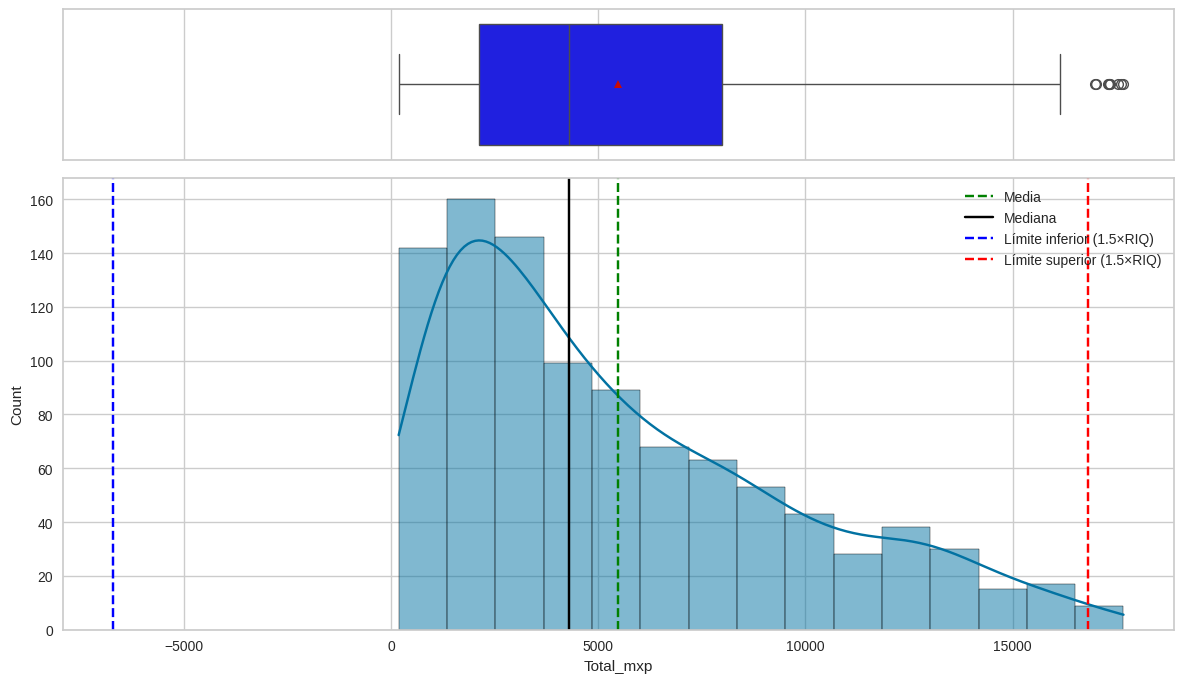

Diagrama para Rating


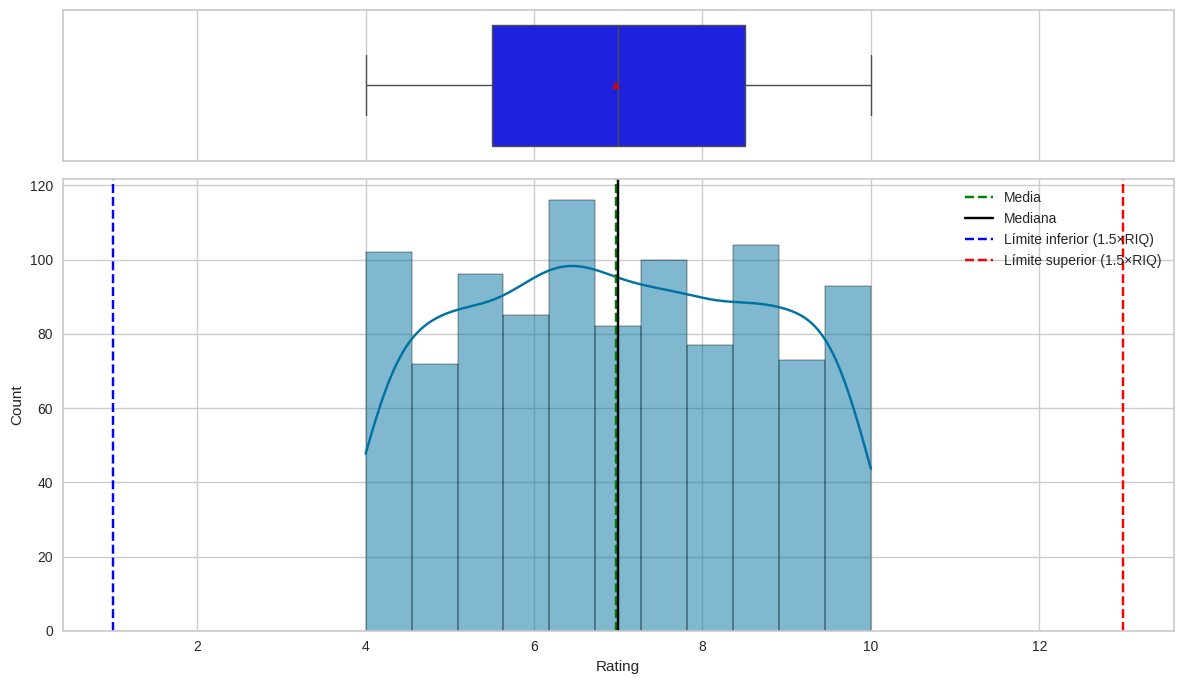

In [ ]:

# Apliquemos la función a las variables numéricas
# Seleccionando todas las columnas numéricas
numeric_columns = df.select_dtypes(include=[np.number]).columns

plt.close('all')
# Aplicar la función a todas las columnas numéricas
for col in numeric_columns:
    print(f"Diagrama para {col}")
    histogram_boxplot(df, col)

**Comentarios de lo anterior:**


Se verificaron todos los comentarios realizados a partir del análisis estadístico básico del conjunto de datos. Inicialmente existía la duda sobre el valor del ticket promedio, ya que la mediana indicaba un monto de $4,303.

Al analizar el boxplot y el histograma, se observó que existen compras totales considerablemente elevadas en comparación con el resto, lo cual genera una asimetría positiva (sesgo a la derecha) en la distribución.

Aunque en el boxplot estos valores son marcados como outliers, no parecen corresponder a errores de captura. No obstante, se procederá a validar esta conclusión incrementando los límites inferior y superior del boxplot, con el fin de evaluar si estos registros siguen siendo considerados atípicos bajo un rango extendido.




In [ ]:
# Mientras hacemos un análisis univariado de variables numéricas, queremos estudiar su tendencia central y dispersión.
# Generemos una función que nos ayudará a crear un diagrama de caja y un histograma para cualquier variable numérica de entrada.
# Esta función toma la columna numérica como entrada y devuelve los diagramas de caja y los histogramas para la variable.

def histogram_boxplot(data, feature, figsize=(12, 7), kde=True, bins=None, mult=1.5):
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,
        sharex=True,
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize)

    # Calcula percentiles y límites basados en el RIQ
    q1 = data[feature].quantile(0.25)
    q3 = data[feature].quantile(0.75)
    iqr = q3 - q1
    mult = 3
    lower_bound = q1 - mult * iqr
    upper_bound = q3 + mult * iqr

    # Boxplot
    sns.boxplot(data=data, x=feature, ax=ax_box2, showmeans=True, color="blue")

    # Histograma
    if bins:
        sns.histplot(data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="spring")
    else:
        sns.histplot(data=data, x=feature, kde=kde, ax=ax_hist2)

    # Líneas verticales para media, mediana y límites
    ax_hist2.axvline(data[feature].mean(), color="green", linestyle="--", label="Media")
    ax_hist2.axvline(data[feature].median(), color="black", linestyle="-", label="Mediana")
    ax_hist2.axvline(lower_bound, color='blue', linestyle='--', label=f'Límite inferior ({mult}×RIQ)')
    ax_hist2.axvline(upper_bound, color='red', linestyle='--', label=f'Límite superior ({mult}×RIQ)')

    ax_hist2.legend()
    plt.tight_layout()
    plt.show()

Diagrama para Unit price_mxp


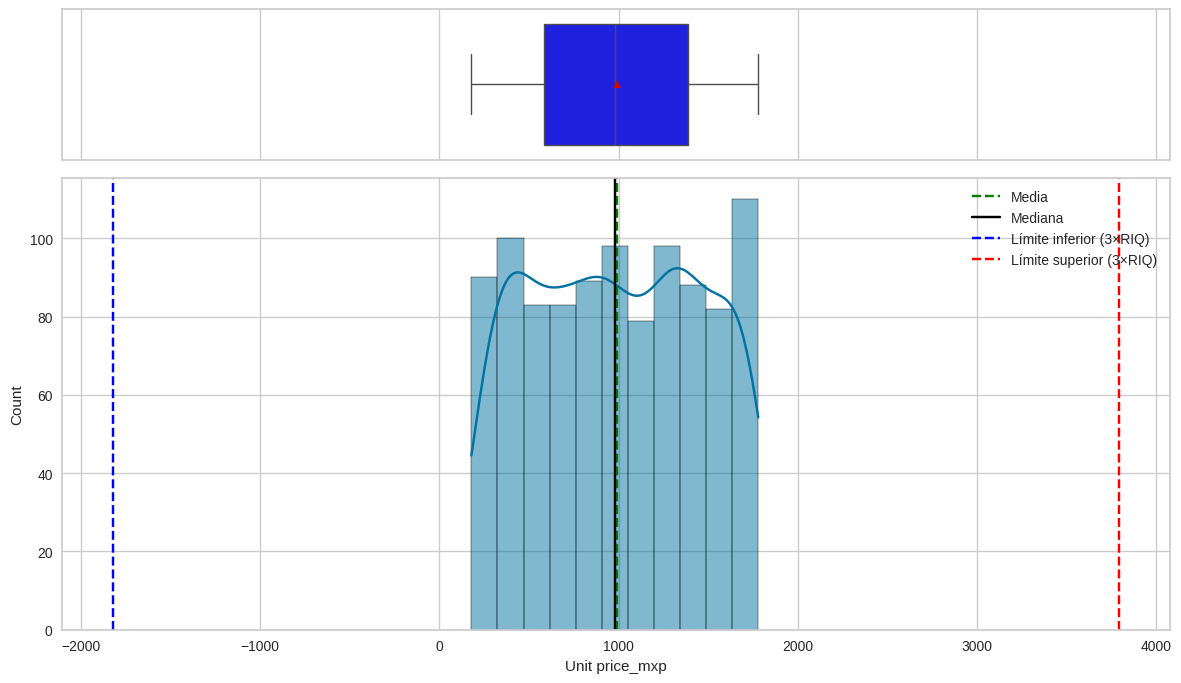

Diagrama para Quantity


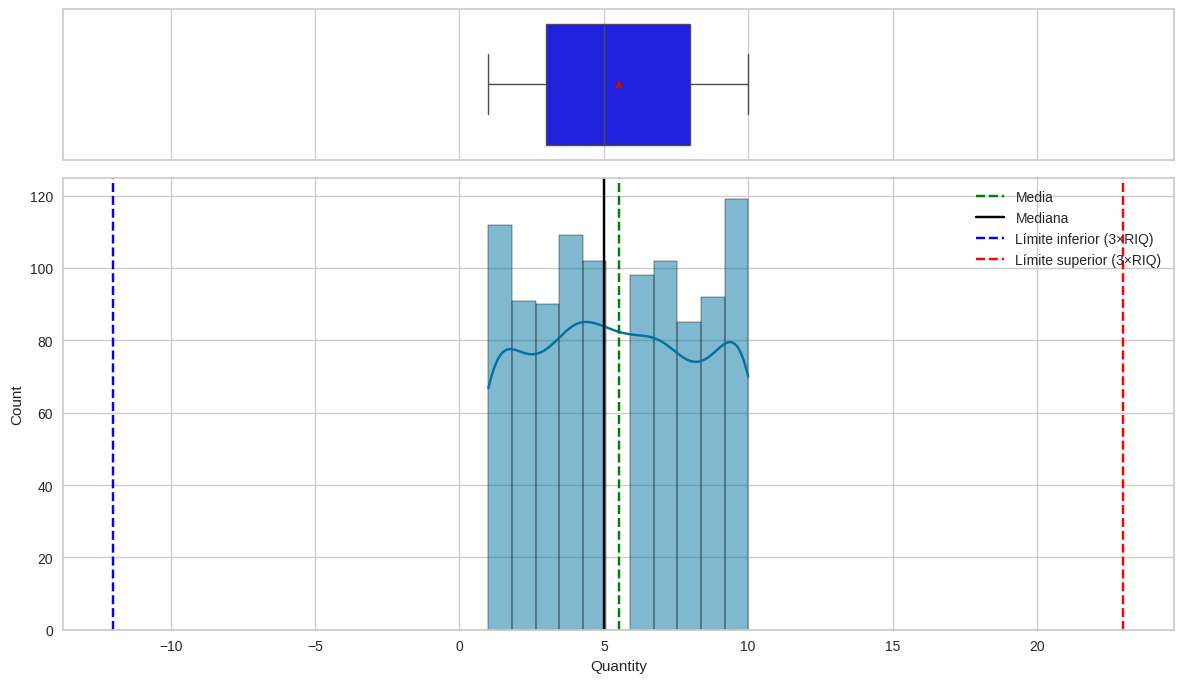

Diagrama para Tax 15%


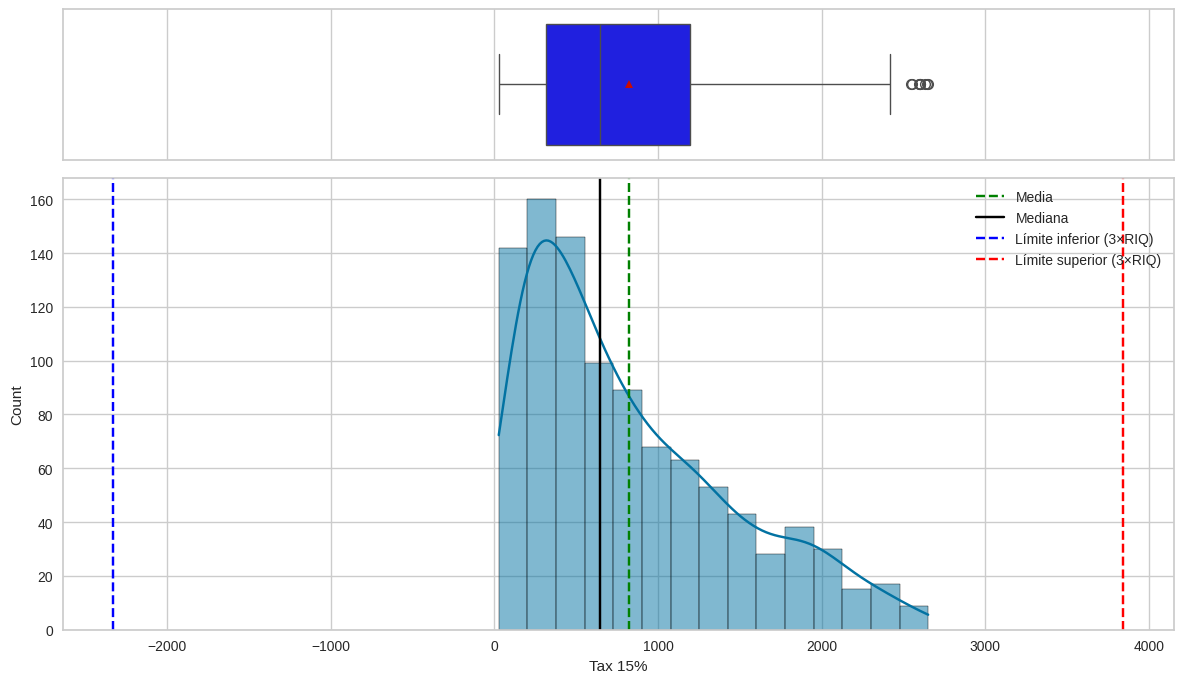

Diagrama para Total_mxp


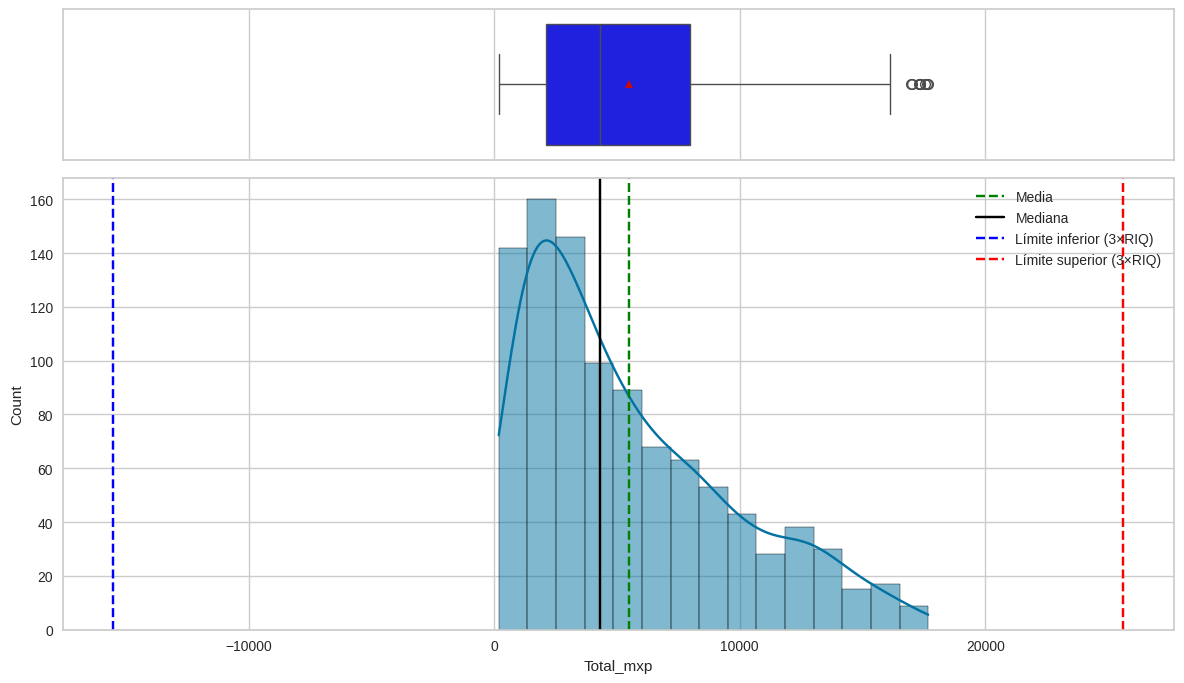

Diagrama para Rating


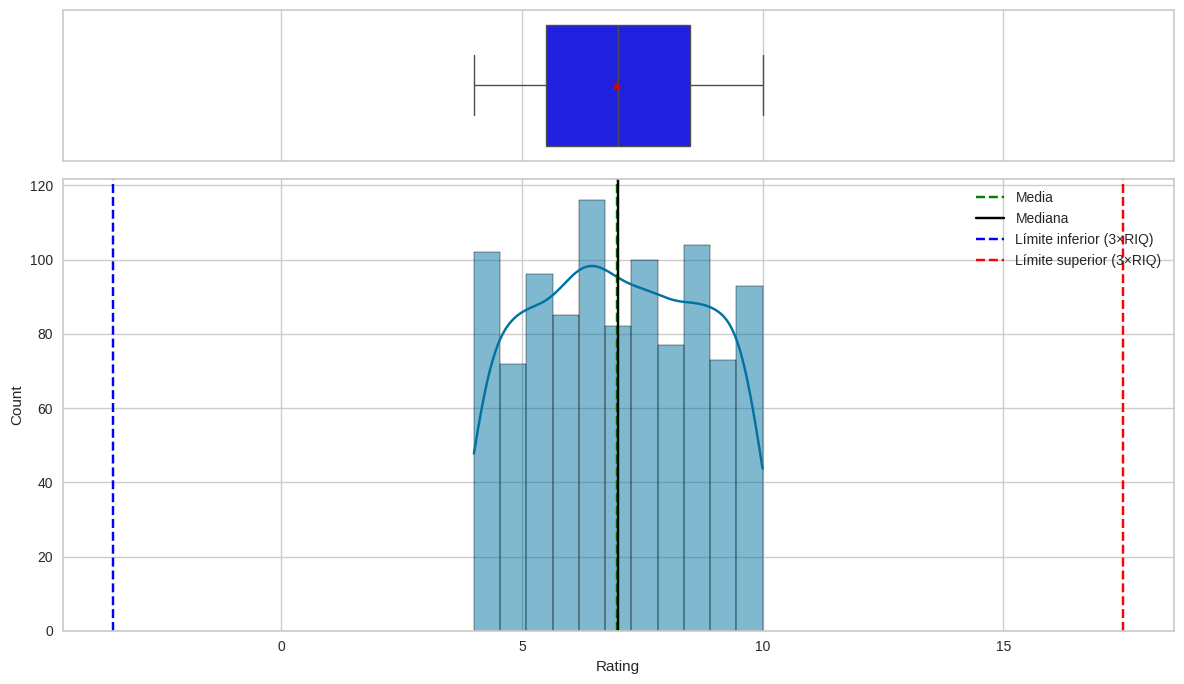

In [ ]:
# Aplicamos nuevamente la funcion perzonalizada para correr los box.plots e historgramas con los limites extendidos.
numeric_columns = df.select_dtypes(include=[np.number]).columns

plt.close('all')
# Aplicar la función a todas las columnas numéricas
for col in numeric_columns:
    print(f"Diagrama para {col}")
    histogram_boxplot(df, col)

**Comentarios:** Efectivamente, estos registros parecen ser outliers, ya que a pesar de haber ampliado los límites establecidos, el análisis continúa identificándolos como valores atípicos.

Sin embargo, es importante considerar que realizaremos un análisis de clustering. Si optamos por un método como DBSCAN, el propio algoritmo identificará estos puntos como outliers y, en consecuencia, no los incluirá en ningún clúster. Por esta razón, decidimos mantener estos registros en el conjunto de datos.

In [ ]:
grandes_compras = df[df['Total_mxp'] > 17000] #Podemos ver que no  hay incosistencia entre el total_mxp y el Tax

# Mostrar los registros filtrados
print(grandes_compras)

      Invoice ID         City Membership  Gender         Product line  \
166  234-65-2137  Guadalajara       Plus    Male   Home and lifestyle   
167  687-47-8271    Mexico DF       Plus    Male  Fashion accessories   
350  860-79-0874  Guadalajara      Nomal  Female  Fashion accessories   
422  271-88-8734  Guadalajara      Nomal  Female  Fashion accessories   
557  283-26-5248  Guadalajara      Nomal  Female   Food and beverages   
699  751-41-9720  Guadalajara       Plus    Male   Home and lifestyle   
792  744-16-7898    Monterrey       Plus  Female   Home and lifestyle   
996  303-96-2227    Monterrey       Plus  Female   Home and lifestyle   

     Unit price_mxp  Quantity   Tax 15%  Total_mxp                 Date  \
166        1701.324        10  2551.986   17013.24            1/16/2019   
167        1761.844        10  2642.766   17618.44  2019-08-02 00:00:00   
350        1767.540        10  2651.310   17675.40            2/15/2019   
422        1730.338        10  2595.507   

### **Resumen estadístico para las variables numéricas**

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unit price_mxp,1000.0,990.963914,471.604385,179.4240,585.175000,983.0940,1387.24300,1779.288
Quantity,1000.0,5.510000,2.923431,1.0000,3.000000,5.0000,8.00000,10.000
Tax 15%,1000.0,821.258305,625.251281,27.1539,316.388325,645.4992,1198.57635,2651.310
Total_mxp,1000.0,5475.055364,4168.341871,181.0260,2109.255500,4303.3280,7990.50900,17675.400
Rating,1000.0,6.972700,1.718580,4.0000,5.500000,7.0000,8.50000,10.000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Invoice ID      1000 non-null   object  
 1   City            1000 non-null   category
 2   Membership      1000 non-null   category
 3   Gender          1000 non-null   category
 4   Product line    1000 non-null   category
 5   Unit price_mxp  1000 non-null   float64 
 6   Quantity        1000 non-null   int64   
 7   Tax 15%         1000 non-null   float64 
 8   Total_mxp       1000 non-null   float64 
 9   Date            1000 non-null   object  
 10  Payment         1000 non-null   category
 11  Rating          1000 non-null   float64 
dtypes: category(5), float64(4), int64(1), object(2)
memory usage: 60.4+ KB


### **Análisis de frecuencias de variables categóricas**

In [ ]:
# Creando una lista de variables categóricas
cat_cols =  ['City', 'Membership', 'Gender',"Product line","Payment"]

# Visualizando los valores únicos
for column in cat_cols:
    print(df[column].value_counts())
    print("_" * 90)

City
Mexico DF      340
Monterrey      332
Guadalajara    328
Name: count, dtype: int64
__________________________________________________________________________________________
Membership
Nomal    501
Plus     499
Name: count, dtype: int64
__________________________________________________________________________________________
Gender
Female    501
Male      499
Name: count, dtype: int64
__________________________________________________________________________________________
Product line
Fashion accessories       178
Food and beverages        174
Electronic accessories    170
Sports and travel         166
Home and lifestyle        160
Health and beauty         152
Name: count, dtype: int64
__________________________________________________________________________________________
Payment
Ewallet        345
Cash           344
Credit card    311
Name: count, dtype: int64
__________________________________________________________________________________________


**Comentario:**

Las variables Invoice ID y Date serán excluidas del análisis, ya que no aportan valor relevante al ejercicio.

En cuanto al resto de las variables categóricas, se mantendrán en el conjunto de datos, ya que podrían aportar información útil al análisis. Para poder utilizarlas en el modelo de clustering, se les aplicará un codificador del tipo One-Hot Encoding.



Eliminamos variables Invoice ID y Date:

In [ ]:
df.drop(['Invoice ID', 'Date',"Membership","City","Payment","Product line"], axis=1, inplace=True)

**Comentario:** Mas adelante aclaramos porque finalmente decidimos eliminar estas variables del analisis. (Ver comentario posterior de la linea 123)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Gender          1000 non-null   category
 1   Unit price_mxp  1000 non-null   float64 
 2   Quantity        1000 non-null   int64   
 3   Tax 15%         1000 non-null   float64 
 4   Total_mxp       1000 non-null   float64 
 5   Rating          1000 non-null   float64 
dtypes: category(1), float64(4), int64(1)
memory usage: 40.3 KB


Se realiza una matriz de correlación utilizando únicamente las variables numéricas, antes de aplicar cualquier técnica de codificación. Esto permite identificar posibles relaciones lineales entre las variables y evitar redundancias en el conjunto de datos que podrían afectar el desempeño del modelo de clustering.

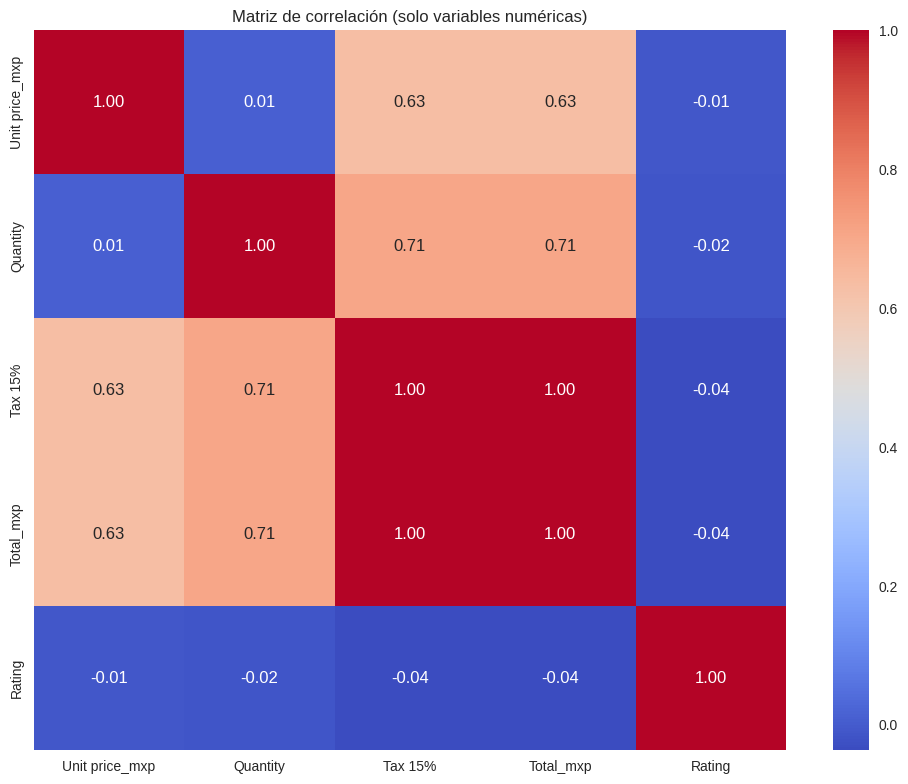

In [ ]:
df_numericas = df.select_dtypes(include=['number'])

# Calcular la matriz de correlación
matriz_corr = df_numericas.corr()

# Graficar la matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de correlación (solo variables numéricas)')
plt.tight_layout()
plt.show()

**Comentario:** Como se puede observar en la matriz de correlación, las variables Total_mxp y Tax 15% presentan una correlación perfecta, lo cual indica una redundancia entre ellas. Por esta razón, se decidió excluir la variable Tax 15% del análisis, ya que su información está completamente contenida en Total_mxp

In [ ]:
df.drop(['Tax 15%'], axis=1, inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Gender          1000 non-null   category
 1   Unit price_mxp  1000 non-null   float64 
 2   Quantity        1000 non-null   int64   
 3   Total_mxp       1000 non-null   float64 
 4   Rating          1000 non-null   float64 
dtypes: category(1), float64(3), int64(1)
memory usage: 32.5 KB


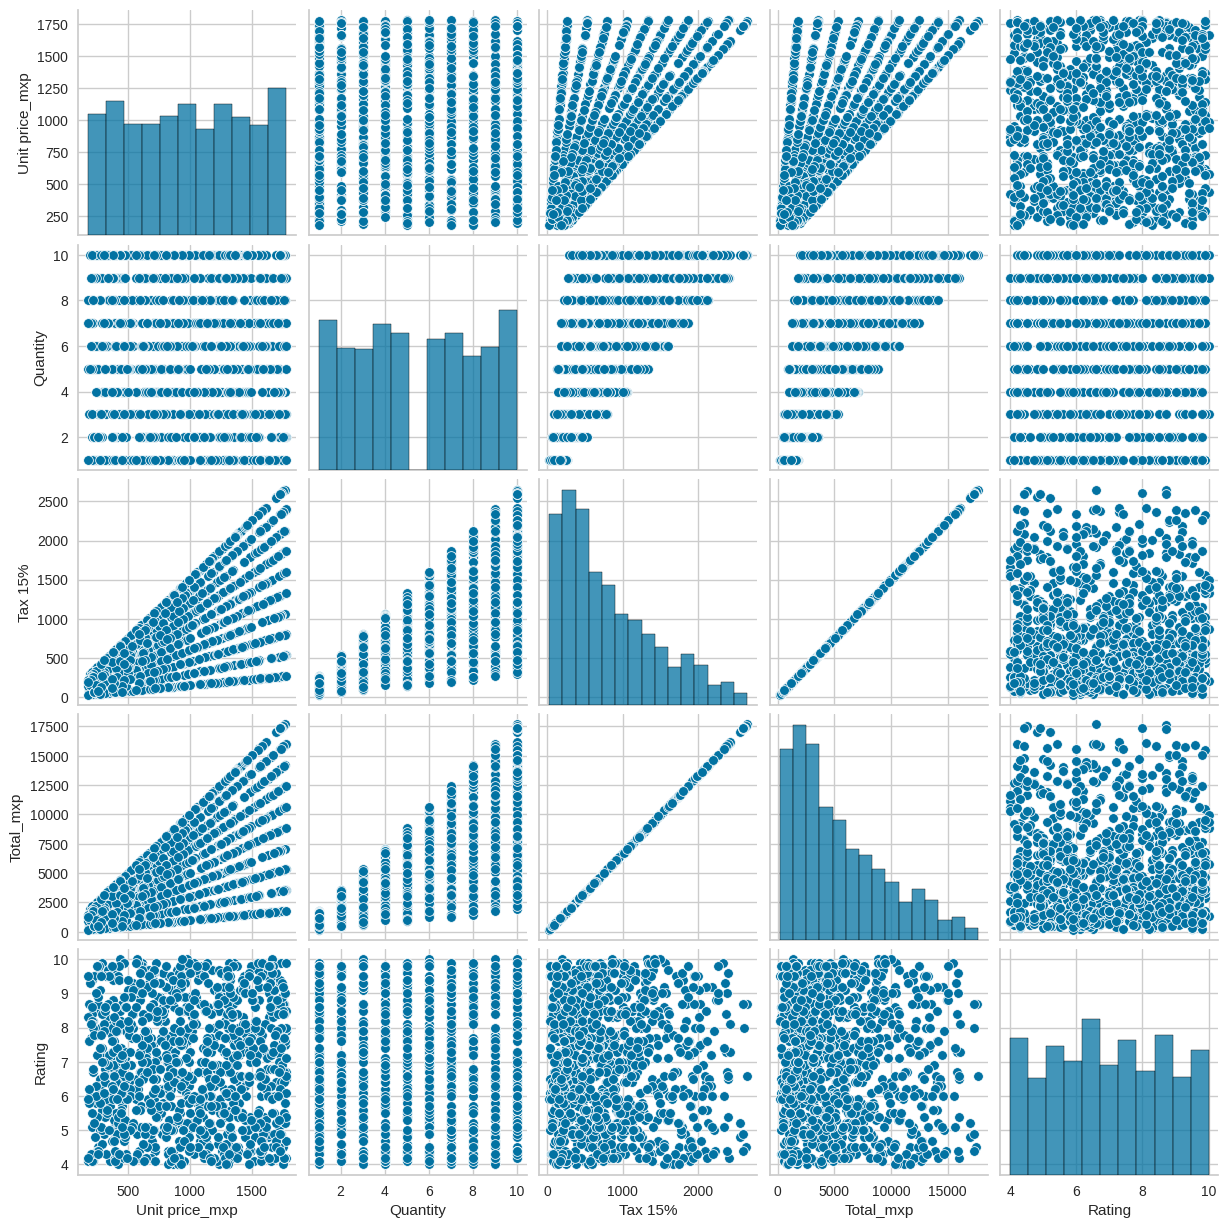

In [ ]:
sns.pairplot(df_numericas)

### **Encoding de variables categóricas**
Apliquemos el one hot encoding a las variables categóricas.

In [ ]:
# Creando una lista de variables categóricas
cat_cols = ["Gender"]

# Realizando One Hot Encoding en las columnas categóricas
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=False)

# Convirtierndo las nuevas columnas a tipo int en logar de booleanos
for col in df_encoded.columns:
    if col.startswith(tuple(cat_cols)):
        df_encoded[col] = df_encoded[col].astype(int)

In [ ]:
df_encoded.head()

,Unit price_mxp,Quantity,Total_mxp,Rating,Gender_Female,Gender_Male
0,1329.482,7,9306.374,9.1,1,0
1,271.984,5,1359.920,9.6,1,0
2,824.674,7,5772.718,7.4,0,1
3,1036.316,8,8290.528,8.4,0,1
4,1536.318,7,10754.226,5.3,0,1


## **Finalmente, la estandarización de las variables numéricas.**

In [ ]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unit price_mxp  1000 non-null   float64
 1   Quantity        1000 non-null   int64  
 2   Total_mxp       1000 non-null   float64
 3   Rating          1000 non-null   float64
 4   Gender_Female   1000 non-null   int64  
 5   Gender_Male     1000 non-null   int64  
dtypes: float64(3), int64(3)
memory usage: 47.0 KB


In [ ]:
from sklearn.preprocessing import StandardScaler

# Seleccionando todas las columnas numéricas
numeric_columns = df_encoded.select_dtypes(include=[np.number]).columns

# Inicializando el escalador
scaler = StandardScaler()

# Aplicando el escalador a las columnas numéricas
df_standard = pd.DataFrame(scaler.fit_transform(df_encoded[numeric_columns]), columns=numeric_columns)

# Concatenando columnas no numéricas (excluyendo las originales categóricas) con el DataFrame estandarizado
df_final = pd.concat([df_encoded.drop(columns=numeric_columns), df_standard], axis=1)

In [ ]:
df_standard.head()

,Unit price_mxp,Quantity,Total_mxp,Rating,Gender_Female,Gender_Male
0,0.718160,0.509930,0.919607,1.238443,0.998002,-0.998002
1,-1.525303,-0.174540,-0.987730,1.529527,0.998002,-0.998002
2,-0.352781,0.509930,0.071446,0.248760,-1.002002,1.002002
3,0.096214,0.852165,0.675780,0.830927,-1.002002,1.002002
4,1.156959,0.509930,1.267125,-0.973790,-1.002002,1.002002


In [ ]:
df_standard.describe().T

,count,mean,std,min,25%,50%,75%,max
Unit price_mxp,1000.0,-2.451372e-16,1.0005,-1.721668,-0.860874,-0.016696,0.840699,1.672416
Quantity,1000.0,6.394885e-17,1.0005,-1.543480,-0.859010,-0.174540,0.852165,1.536635
Total_mxp,1000.0,9.592327e-17,1.0005,-1.270692,-0.807871,-0.281242,0.603768,2.928371
Rating,1000.0,1.882938e-16,1.0005,-1.730607,-0.857357,0.015893,0.889143,1.762394
Gender_Female,1000.0,-5.151435e-17,1.0005,-1.002002,-1.002002,0.998002,0.998002,0.998002
Gender_Male,1000.0,5.151435e-17,1.0005,-0.998002,-0.998002,-0.998002,1.002002,1.002002


Diagrama para Unit price_mxp


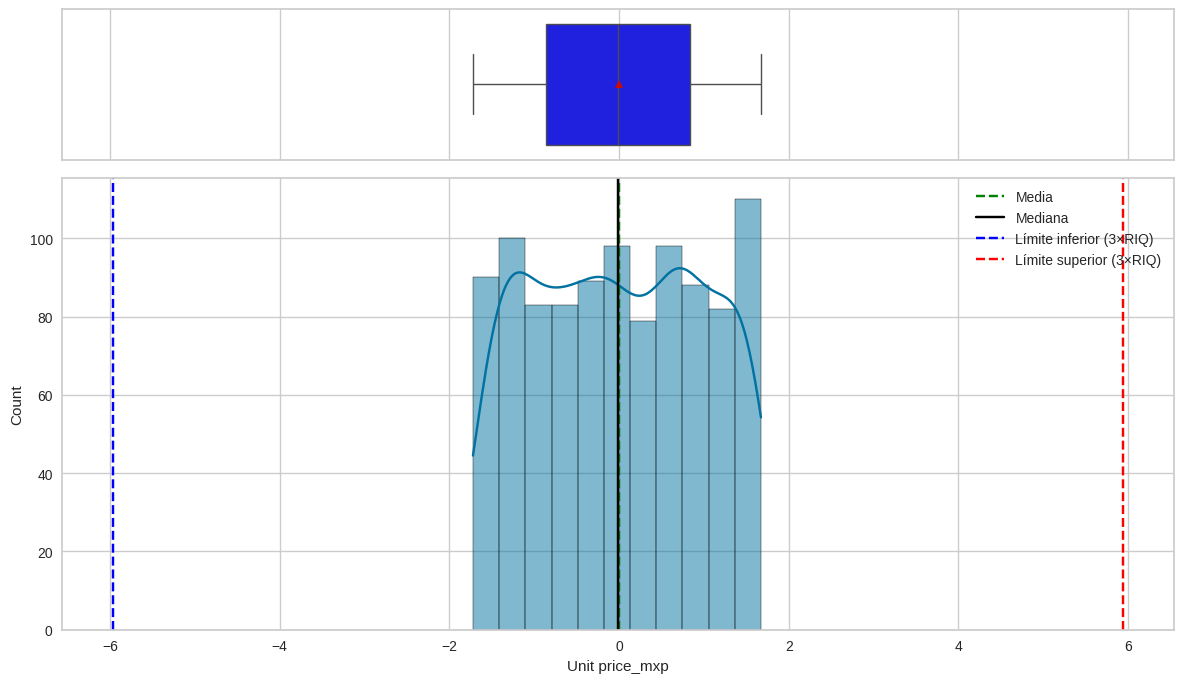

Diagrama para Quantity


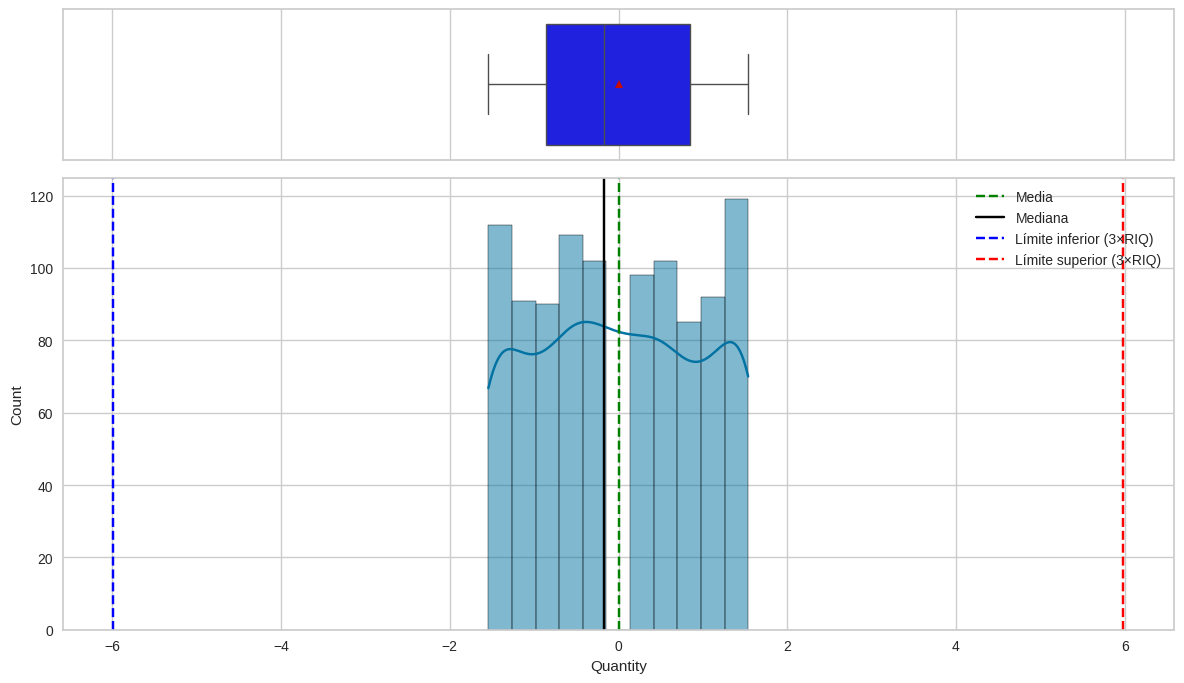

Diagrama para Total_mxp


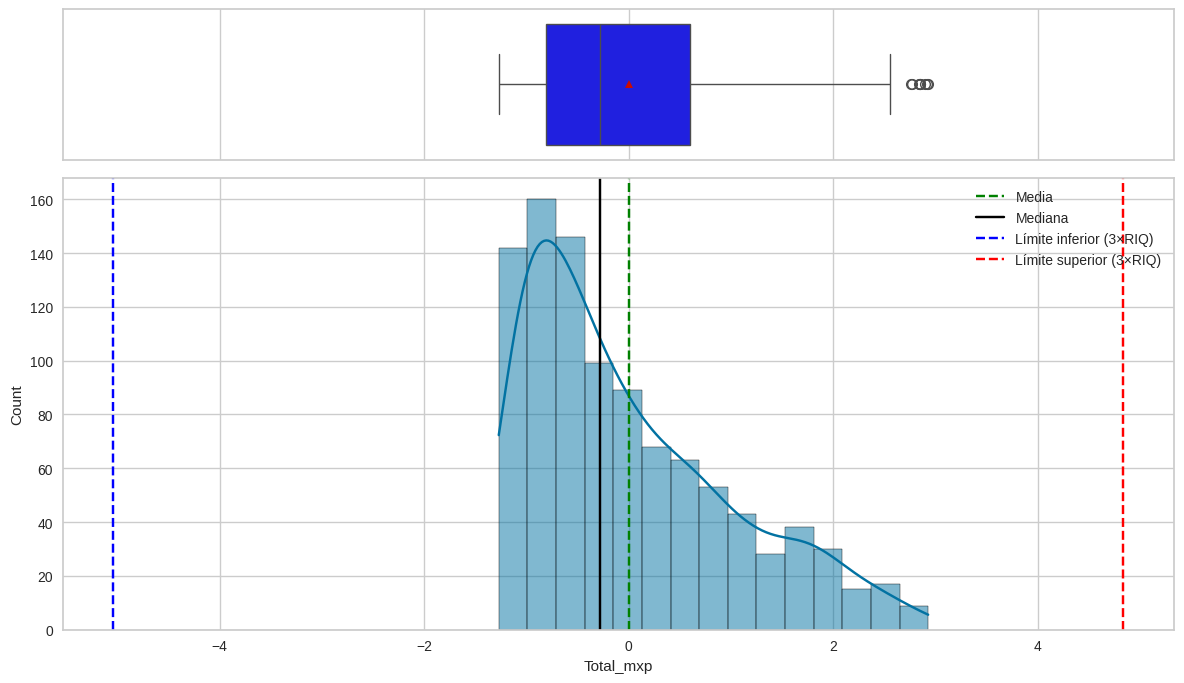

Diagrama para Rating


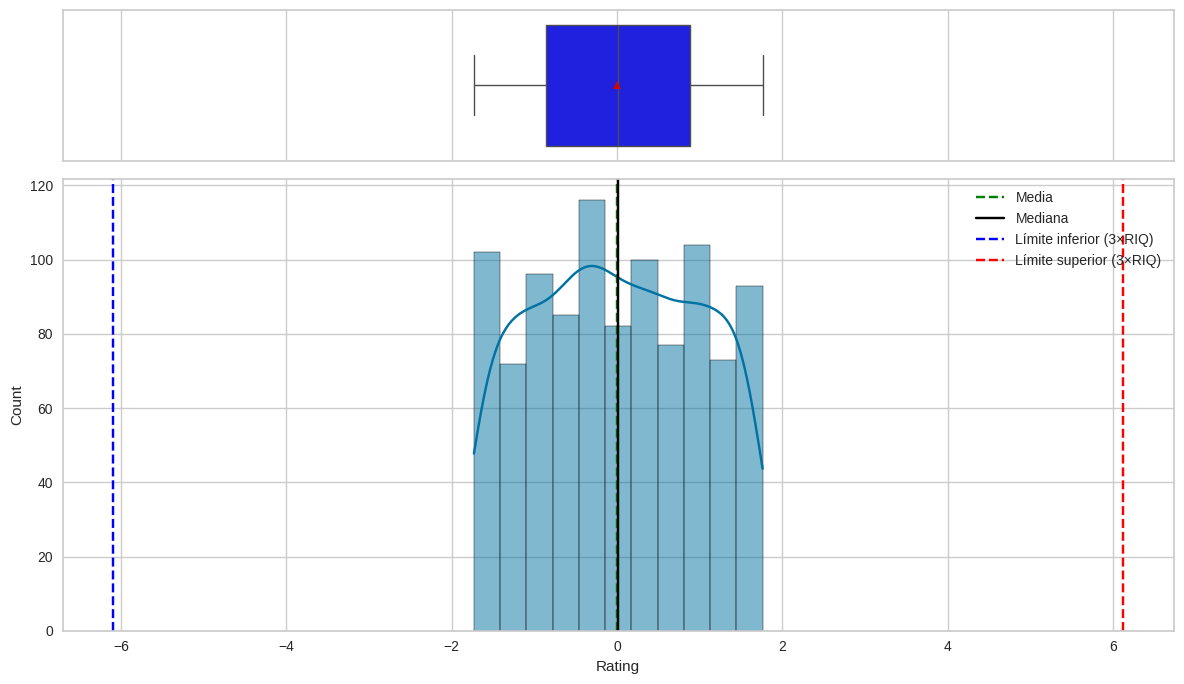

Diagrama para Gender_Female


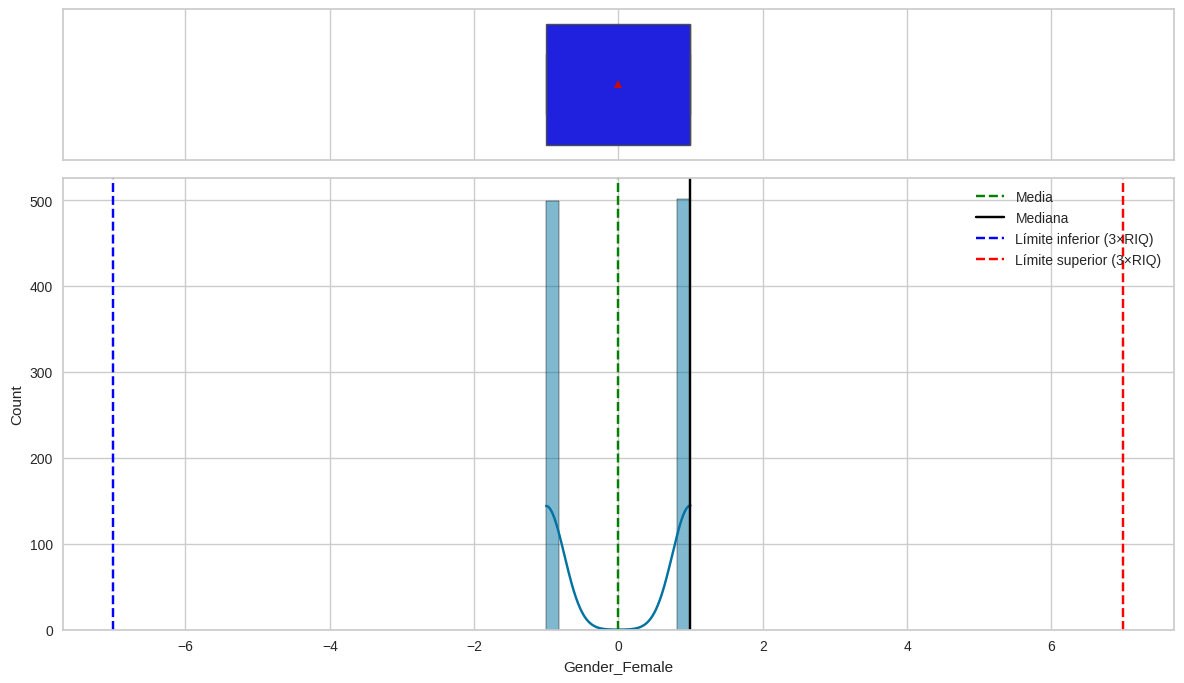

Diagrama para Gender_Male


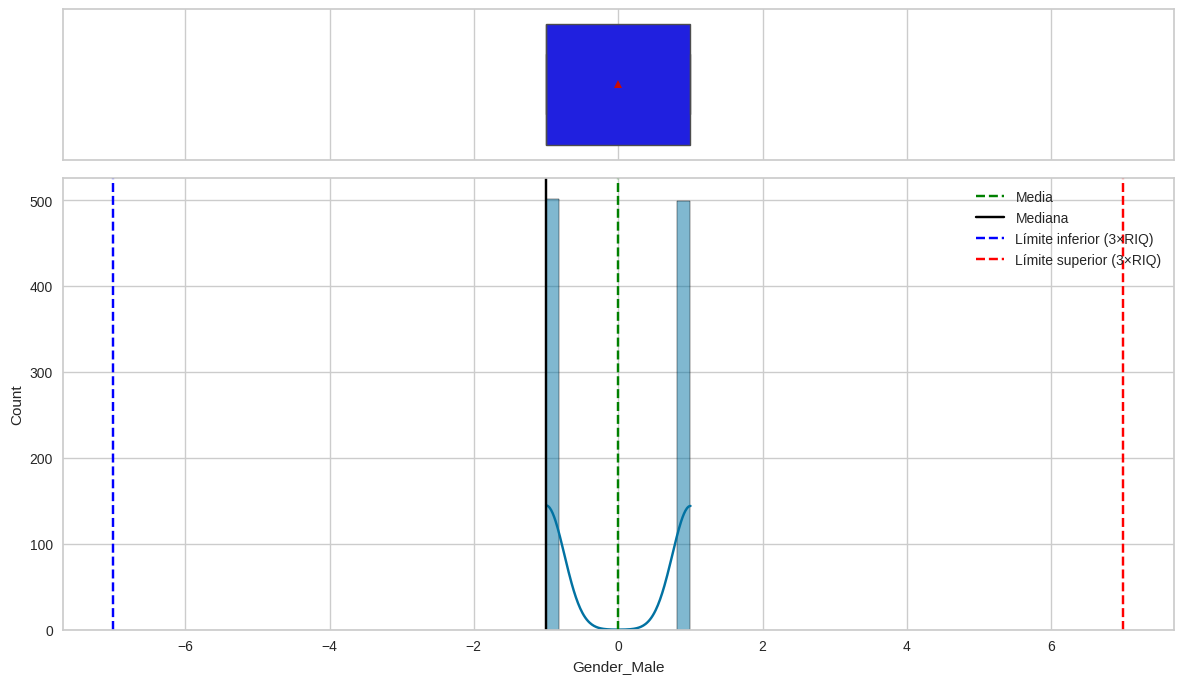

In [ ]:
# Apliquemos la función a las variables numéricas
# USAREMOS la nueva BD df_standard
# Seleccionando todas las columnas numéricas
numeric_columns = df_standard.select_dtypes(include=[np.number]).columns
# Aplicar la función a todas las columnas numéricas
for col in numeric_columns:
    print(f"Diagrama para {col}")
    histogram_boxplot(df_standard, col)

# **Aplicación de los modelos de clustering**

En este paso aplicaremos varios algoritmos de clustering y verificaremos cuál es el mejor para nuestro conjunto de datos. Vamos a utilizar los siguientes algoritmos:

- Clustering con K-means
- Clustering aglomerativo
- Clustering basado en el modelo GaussianMixture
- Clustering con DBSCAN

**Primero definimos el mejor valor de K con la tecnica del codo**


En primer lugar, se determina el valor óptimo de K utilizando la técnica del codo (elbow method). Esta técnica permite identificar el número adecuado de clústeres al analizar la variación de la inercia intra-clúster en función del número de grupos propuestos.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import missingno as msno
pd.pandas.set_option('display.max_columns',None)

from scipy import stats
from scipy.stats import norm, skew
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import KMeans,AgglomerativeClustering,DBSCAN
from sklearn.mixture import GaussianMixture

from sklearn.metrics import silhouette_samples, silhouette_score

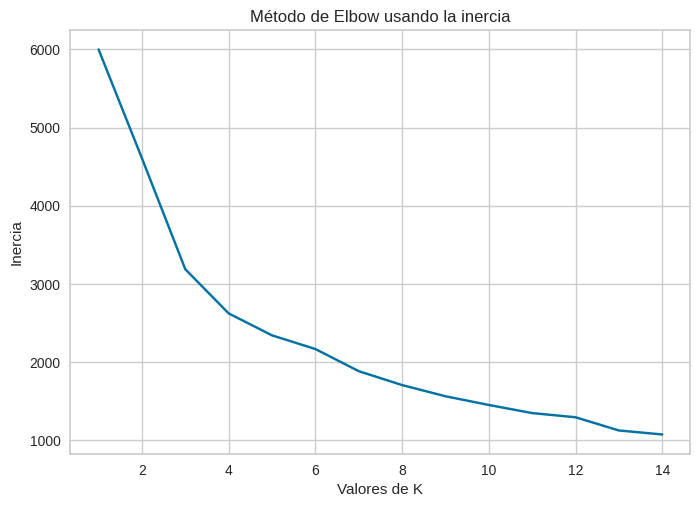

In [ ]:
inertia = []
range_val = range(1,15)
for i in range_val:
  kmean = KMeans(n_clusters=i)
  kmean.fit_predict(pd.DataFrame(df_standard))
  inertia.append(kmean.inertia_)
plt.plot(range_val,inertia,'bx-')
plt.xlabel('Valores de K')
plt.ylabel('Inercia')
plt.title('Método de Elbow usando la inercia')
plt.show()


Del método del codo mencionado anteriormente, vemos que **K = 3** es el mejor valor de K para nuestro clustering.




Apliquemos ahora el análisis de silueta integral, para reforzar esta decisión.

In [ ]:
from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [ ]:
# Definamos el rango de clústeres a evaluar
range_n_clusters = list(range(2, 9))

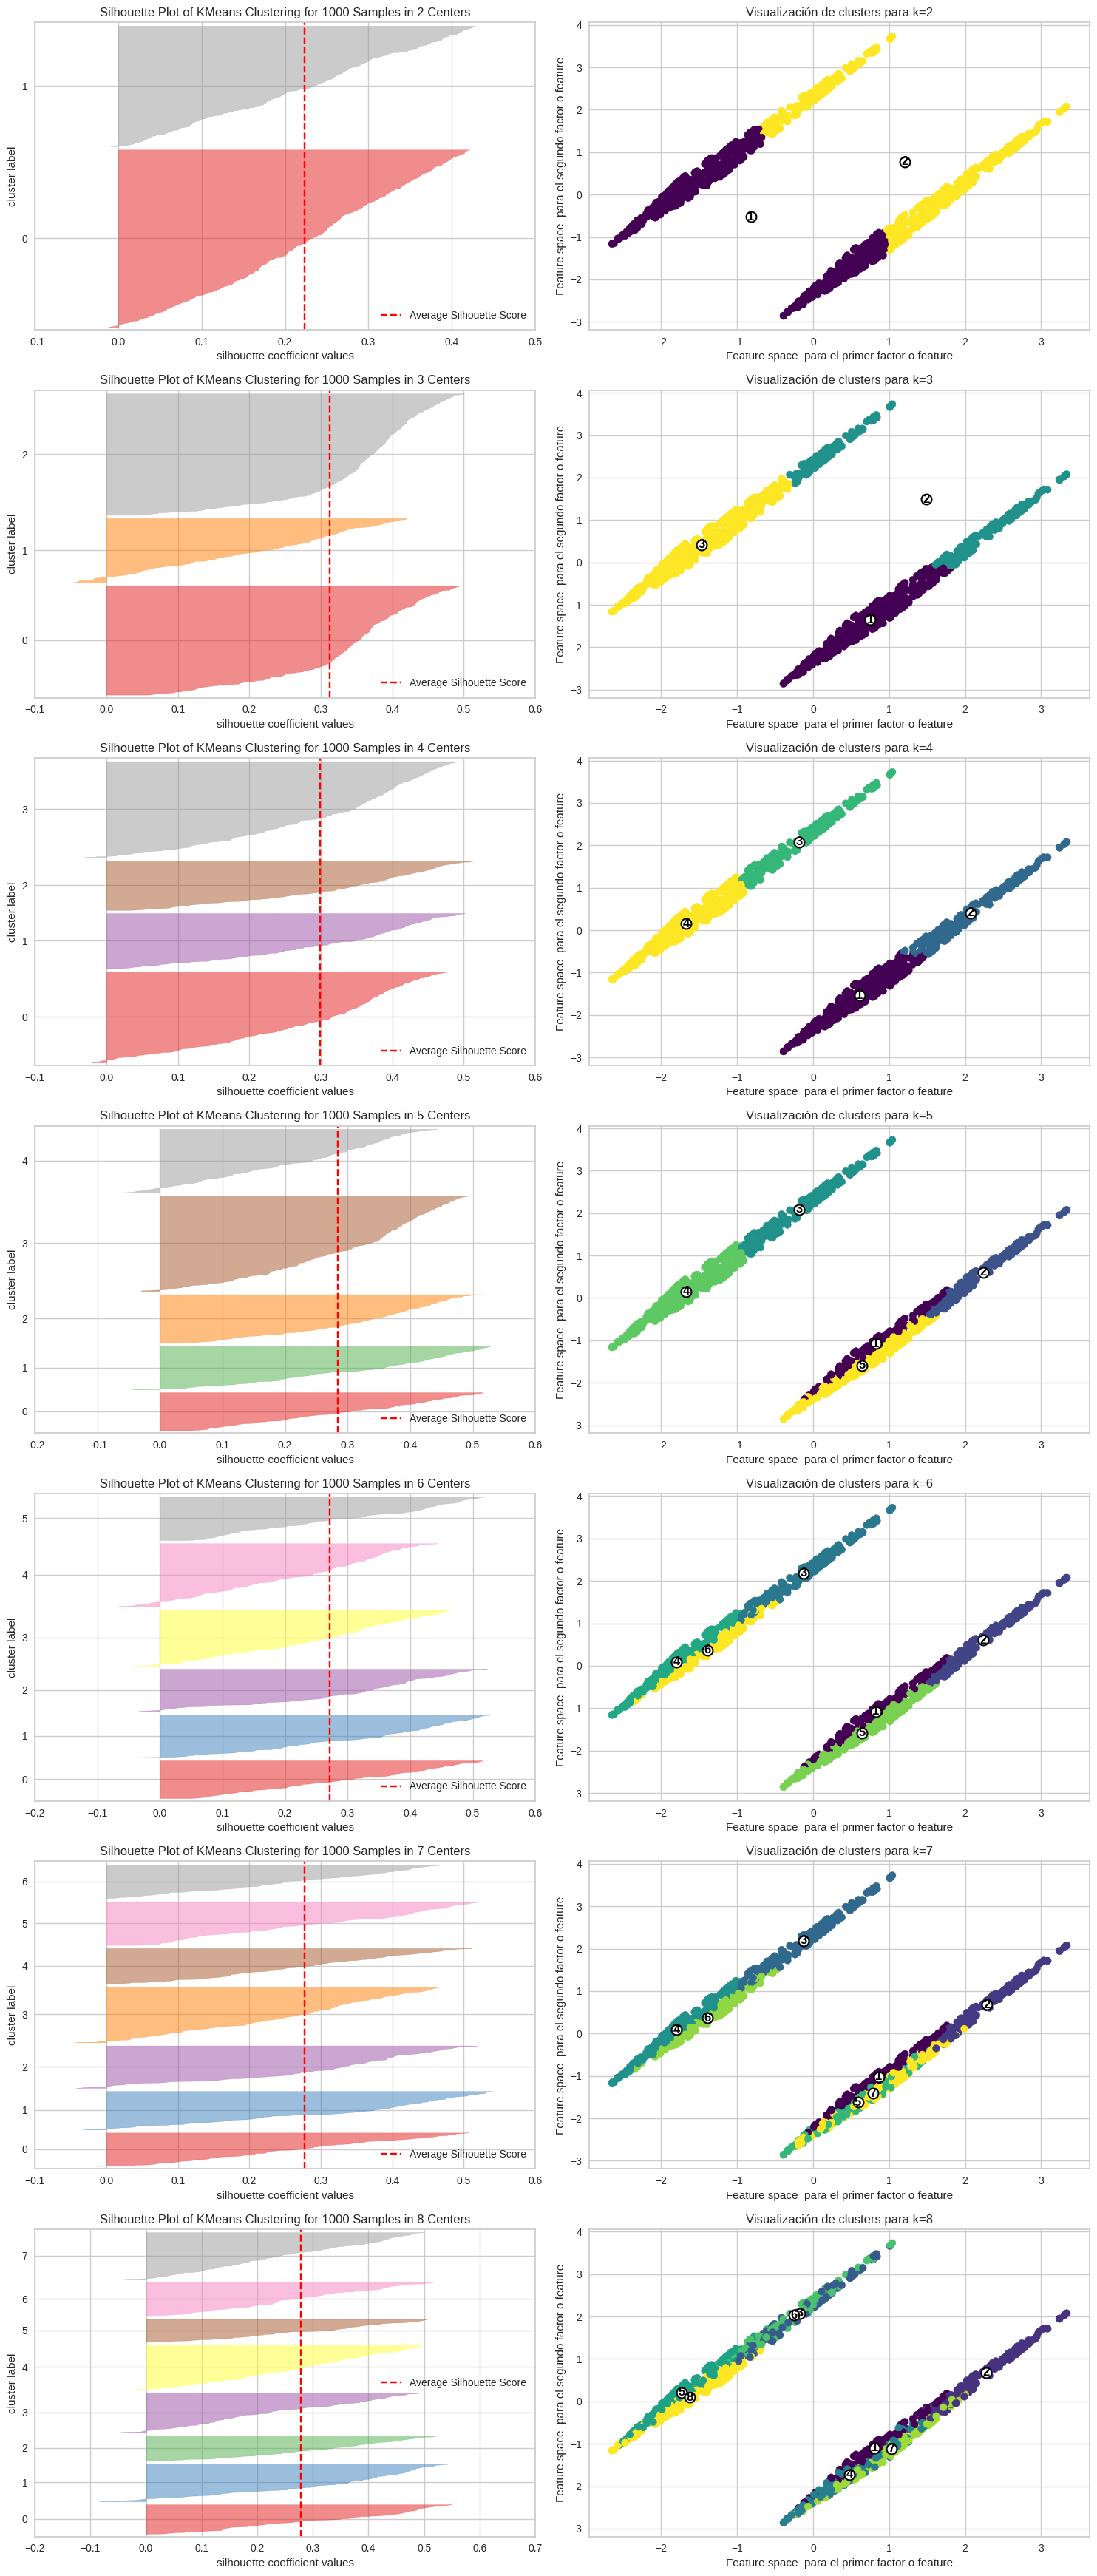

In [ ]:
# Creando una figura con subplots
fig, axs = plt.subplots(len(range_n_clusters), 2, figsize=(15, 5 * len(range_n_clusters)))

# Iterando sobre el rango de clústeres
for i, n_clusters in enumerate(range_n_clusters):
    # Crear una instancia de KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=1)

    # Creando el visualizador de silueta
    visualizer = SilhouetteVisualizer(kmeans, ax=axs[i, 0])
    visualizer.fit(df_standard)
    visualizer.finalize()

    # Ajustando KMeans a los datos
    kmeans.fit(df_standard)
    cluster_labels = kmeans.labels_
    centroids = kmeans.cluster_centers_

    # Reduciendo la dimensionalidad a 2D para la visualización
    pca = PCA(n_components=2)
    reduced_data = pca.fit_transform(df_standard)
    reduced_centroids = pca.transform(centroids)

    # Creando scatter plot para la visualización de clústeres
    scatter = axs[i, 1].scatter(reduced_data[:, 0], reduced_data[:, 1], c=cluster_labels, cmap='viridis')
    axs[i, 1].set_title(f'Visualización de clusters para k={n_clusters}')
    axs[i, 1].set_xlabel('Feature space  para el primer factor o feature')
    axs[i, 1].set_ylabel('Feature space  para el segundo factor o feature')

    # Añadiendo centroides con números en círculos
    for j, centroid in enumerate(reduced_centroids):
        axs[i, 1].scatter(centroid[0], centroid[1], marker='o', s=100, c='white', edgecolor='black', linewidth=1.5)
        axs[i, 1].text(centroid[0], centroid[1], str(j+1), color='black', ha='center', va='center', weight='bold')

# Ajustando los subplots
plt.tight_layout()
plt.show()

**Comentario iteracion 1:**

"En el análisis con la técnica del codo, se observa que el valor óptimo de K se encuentra en un rango entre 3 y 5. Sin embargo, al aplicar el análisis de índice de silueta, no se evidencia una separación clara entre los clústeres dentro de ese mismo rango.

Esto podría deberse a la inclusión de variables categóricas, las cuales, al haber sido codificadas mediante One-Hot Encoding, pueden estar introduciendo complejidad adicional en la estructura del espacio de características, dificultando así una asignación clara a los clústeres."


**Se realizaron diversas iteraciones utilizando distintas combinaciones de variables categóricas, y en prácticamente todos los casos se observó el mismo fenómeno: los resultados del análisis de silueta integral mostraban una buena agrupación únicamente en el límite inferior del rango de valores recomendados para K, lo cual no es ideal desde el punto de vista interpretativo ni estadístico.**

**Por esta razón, se optó por realizar el ejercicio utilizando únicamente la variable Gender, observándose en este caso una asignación más clara y consistente de los clústeres. Lo anterior fue lo que observamos en los graficos presentados.**

# **Primera interacion considernado las variables categoricas**

**Elbow Method resultante con todas las variables categoricas menos Invoice ID:**


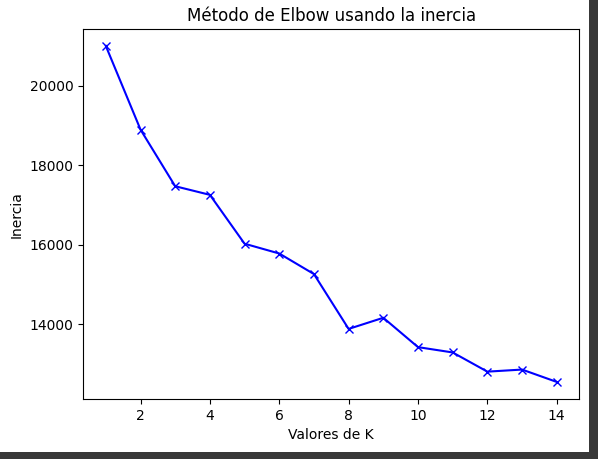


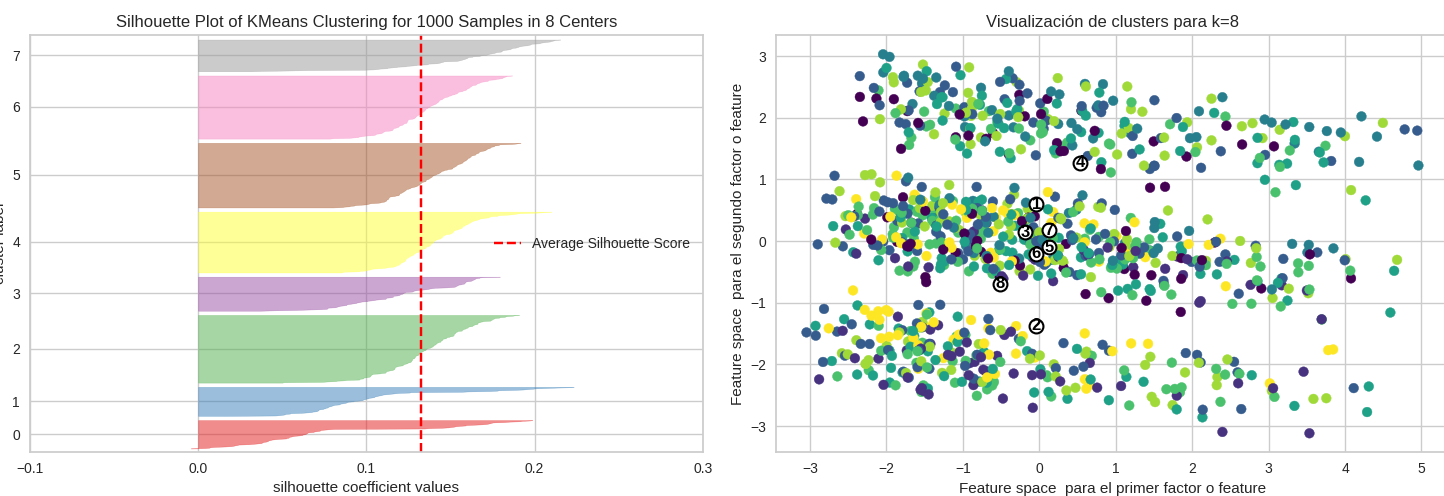



**K-Means Clustering**

In [ ]:
# Apliquemos k-means con 4 clusters
kmeans_model=KMeans(3)
kmeans_clusters = kmeans_model.fit_predict(df_standard)

**Clustering Jerárquico**

In [ ]:
# apply agglomerative algorithm
agglo_model = AgglomerativeClustering(linkage="ward",n_clusters=(3))
agglomerative_clusters = agglo_model.fit_predict(df_standard)

**GaussianMixture Model (GMM)**

In [ ]:
GaussianMixture_model = GaussianMixture(n_components=3)
gmm_clusters = GaussianMixture_model.fit_predict(df_standard)

**DBSCAN**

In [ ]:
model_dbscan = DBSCAN(eps=2, min_samples=20)
dbscan_clusters = model_dbscan.fit_predict(df_standard)

## **Índices de Validez del Clustering**

- Utilizaremos el método de la puntuación de silueta para elegir el mejor algoritmo de clustering.

In [ ]:
from sklearn.metrics import silhouette_score

def silhouette_method(df, algo, y_pred):
    n_clusters = len(set(y_pred)) - (1 if -1 in y_pred else 0)
    if n_clusters > 1:
        score = silhouette_score(df, y_pred)
        print(f'Clustering {algo} : silhouette score : {score}')
    else:
        print(f'Clustering {algo} : no se puede calcular el silhouette score con {n_clusters} cluster(s)')

print('=================================================================================')
silhouette_method(df_standard, 'KMeans', kmeans_clusters)
silhouette_method(df_standard, 'Agglomerative', agglomerative_clusters)
silhouette_method(df_standard, 'GaussianMixture', gmm_clusters)
silhouette_method(df_standard, 'DBSCAN', dbscan_clusters)
print('=================================================================================')

Clustering KMeans : silhouette score : 0.3128979648075327
Clustering Agglomerative : silhouette score : 0.28159010058806255
Clustering GaussianMixture : silhouette score : 0.25686222184711094
Clustering DBSCAN : silhouette score : 0.33663122377928106


**Comentario:** Se observa que el algoritmo DBSCAN presenta un índice de silueta más alto en comparación con los demás métodos evaluados. Por lo tanto, se selecciona DBSCAN como el modelo final para llevar a cabo el análisis de clustering. En este punto no sabemos cuanntos clusters fueron asignados.

Después de visualizar los clústeres en 3D, se observó que el algoritmo DBSCAN asignó unicamente 2 clusters, lo cual no es favorable al considerar que ese valor de k se encuentra dentro del limite inferior sugerido por el metodo del codo.

Con base en el análisis previo, a partir de este punto se opta por utilizar el algoritmo K-Means, al ser el segundo con la puntuación más alta en el índice de silueta.

### **Veamos ahora la integración de los casos a cada uno de los resultados de k-means, aglomerativo (jerárquico) y GMM**

Generemos las asignaciones de clusters para cada caso, para cada modelo.

In [ ]:
X = df_standard.copy()

# Aplicar los modelos por separado
kmeans_labels = KMeans(n_clusters=3).fit_predict(X)
agglo_labels = AgglomerativeClustering(linkage="ward", n_clusters=3).fit_predict(X)
gmm_labels = GaussianMixture(n_components=3).fit_predict(X)
dbscan_labels = DBSCAN(eps=2, min_samples=20).fit_predict(X)

In [ ]:
# Ahora sí agregamos las etiquetas como columnas al final
df_standard['kmeans_clusters'] = kmeans_labels
df_standard['agglomerative_clusters'] = agglo_labels
df_standard['gmm_clusters'] = gmm_labels
df_standard['dbscan_clusters'] = dbscan_labels

Generemos los clústers de pertenencia en la base de datos original para efectos de desarrollar un mejor análisis.

In [ ]:
df_encoded['kmeans_clusters'] = kmeans_labels
df_encoded['agglomerative_clusters'] = agglo_labels
df_encoded['gmm_clusters'] = gmm_labels
df_encoded['dbscan_clusters'] = dbscan_labels

df_encoded

,Unit price_mxp,Quantity,Total_mxp,Rating,Gender_Female,Gender_Male,kmeans_clusters,agglomerative_clusters,gmm_clusters,dbscan_clusters
0,1329.482,7,9306.374,9.1,1,0,0,0,1,0
1,271.984,5,1359.920,9.6,1,0,0,2,1,0
2,824.674,7,5772.718,7.4,0,1,1,1,2,1
3,1036.316,8,8290.528,8.4,0,1,1,1,2,1
4,1536.318,7,10754.226,5.3,0,1,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...
995,718.230,1,718.230,6.2,0,1,1,1,2,1
996,1733.364,10,17333.640,4.4,1,0,2,0,0,0
997,566.752,1,566.752,7.7,0,1,1,1,2,1
998,1171.596,1,1171.596,4.1,0,1,1,1,2,1


### **Visualizando los clusters en un gráfico 3-D**

In [ ]:
# Importando Plotly
import plotly.express as px
# Ver las posibilidades de 3D de Plotly: https://plotly.com/python/3d-axes/
# Definiendo un mapa de color discreto para 5 clusters
color_discrete_map = {
    1: 'red',
    2: 'blue',
    3: 'green',
    4: 'purple',
    5: 'orange'}

### **Gráfico para DBSCAN**

In [ ]:
df_standard['dbscan_clusters'] = df_standard['dbscan_clusters'].astype(str)

#Creando el gráfico con las variables Age, Annual Income (k$) y Spending Score
fig = px.scatter_3d(df_standard,
                    x='Total_mxp',
                    y='Rating',
                    z='Quantity',
                    color='dbscan_clusters',
                    color_discrete_map=color_discrete_map,
                    title='DBSCAN. Distribución de Clusters por age, Annual Income (k$) y Spending Score (1-100)')
fig.update_layout(coloraxis_showscale=True)

fig.show()

### **Gráfico para k-means**

In [ ]:
df_standard['kmeans_clusters'] = df_standard['kmeans_clusters'].astype(str)

#Creando el gráfico con las variables Age, Annual Income (k$) y Spending Score
fig = px.scatter_3d(df_standard,
                    x='Total_mxp',
                    y='Rating',
                    z='Quantity',
                    color='kmeans_clusters',
                    color_discrete_map=color_discrete_map,
                    title='K-MEANS. Distribución de Clusters por age, Annual Income (k$) y Spending Score (1-100)')
fig.update_layout(coloraxis_showscale=True)

fig.show()

### **Gráfico para Aglomerativo (Jerárquico)**

In [ ]:
df_standard['agglomerative_clusters'] = df_standard['agglomerative_clusters'].astype(str)

#Creando el gráfico con las variables Age, Annual Income (k$) y Spending Score
fig = px.scatter_3d(df_standard,
                    x='Total_mxp',
                    y='Rating',
                    z='Quantity',
                    color='agglomerative_clusters',
                    color_discrete_map=color_discrete_map,
                    title='JERÁRQUICO. Distribución de Clusters por age, Annual Income (k$) y Spending Score (1-100)')
fig.update_layout(coloraxis_showscale=True)

fig.show()

### **Gráfico para GMM**

In [ ]:
df_standard['gmm_clusters'] = df_standard['gmm_clusters'].astype(str)

#Creando el gráfico con las variables Age, Annual Income (k$) y Spending Score
fig = px.scatter_3d(df_standard,
                    x='Total_mxp',
                    y='Rating',
                    z='Quantity',
                    color='gmm_clusters',
                    color_discrete_map=color_discrete_map,
                    title='GMM. Distribución de Clusters por age, Annual Income (k$) y Spending Score (1-100)')
fig.update_layout(coloraxis_showscale=True)

fig.show()

In [ ]:
# Comparar las asignaciones de clusters
comparacion_clusters = df_standard[['kmeans_clusters', 'agglomerative_clusters', 'gmm_clusters','dbscan_clusters' ]]

# Mostrar una muestra de la comparación
print(comparacion_clusters.head(20))

print ('===========================================================================================')

# Calcular la proporción de coincidencia entre los métodos
kmeans_vs_agglo = (df_standard['kmeans_clusters'] == df_standard['agglomerative_clusters']).mean()
kmeans_vs_gmm = (df_standard['kmeans_clusters'] == df_standard['gmm_clusters']).mean()
agglo_vs_gmm = (df_standard['agglomerative_clusters'] == df_standard['gmm_clusters']).mean()
dbscan_vs_agglo = (df_standard['dbscan_clusters'] == df_standard['agglomerative_clusters']).mean()
dbscan_vs_gmm = (df_standard['dbscan_clusters'] == df_standard['gmm_clusters']).mean()
dbscan_vs_kmeans = (df_standard['dbscan_clusters'] == df_standard['kmeans_clusters']).mean()

print(f"Proporción de coincidencia entre KMeans y Agglomerative: {kmeans_vs_agglo:.2f}")
print(f"Proporción de coincidencia entre KMeans y GMM: {kmeans_vs_gmm:.2f}")
print(f"Proporción de coincidencia entre Agglomerative y GMM: {agglo_vs_gmm:.2f}")
print(f"Proporción de coincidencia entre DBSCAN y Agglomerative: {dbscan_vs_agglo:.2f}")
print(f"Proporción de coincidencia entre DBSCAN y GMM: {dbscan_vs_gmm:.2f}")

   kmeans_clusters agglomerative_clusters gmm_clusters dbscan_clusters
0                0                      0            1               0
1                0                      2            1               0
2                1                      1            2               1
3                1                      1            2               1
4                2                      0            2               1
5                2                      0            2               1
6                0                      2            1               0
7                2                      0            0               0
8                0                      2            1               0
9                0                      2            1               0
10               0                      2            1               0
11               1                      1            2               1
12               0                      2            1               0
13    

**Comentario:**
1. Se puede observar que existe una alta similitud en las asignaciones realizadas por los algoritmos K-Means y Agglomerative Clustering, lo cual puede explicarse por la naturaleza de ambos algoritmos, ya que los dos se basan en medidas de distancia.
Por otro lado, a pesar de que los algoritmos Agglomerative y DBSCAN tienen fundamentos muy distintos —basados en densidades y distancias, respectivamente—, presentan un índice de coincidencia de 0.49 en sus asignaciones.

2. La elección final del algoritmo de clustering depende en gran medida de la forma y distribución de los datos. En este sentido, GMM es particularmente adecuado para conjuntos de datos con estructuras similares a "bastones" o "galaxias", ya que modela la densidad como una combinación de distribuciones gaussianas.
Si recordamos el análisis previo del índice de silueta integral, se observaba precisamente una distribución con forma de bastón, lo cual respalda el uso de GMM como una alternativa viable.

3. Sin embargo en el perfilamiento, observamos que tanto K-means como GMM consideran la variable Total_mxp como una de las que mejor delimitan los grupos. Sin embargo, en GMM la distribución de los clusters es más amplia, lo que se evidencia en el mayor tamaño de las cajas en los box-plots. En contraste, en K-means se aprecia el efecto opuesto, con clusters más compactos y agrupados según su distribución.


   KMeans  Agglomerative  GMM  DBSCAN
0     398            274  119   501.0
1     400            356  438   499.0
2     202            370  443     NaN


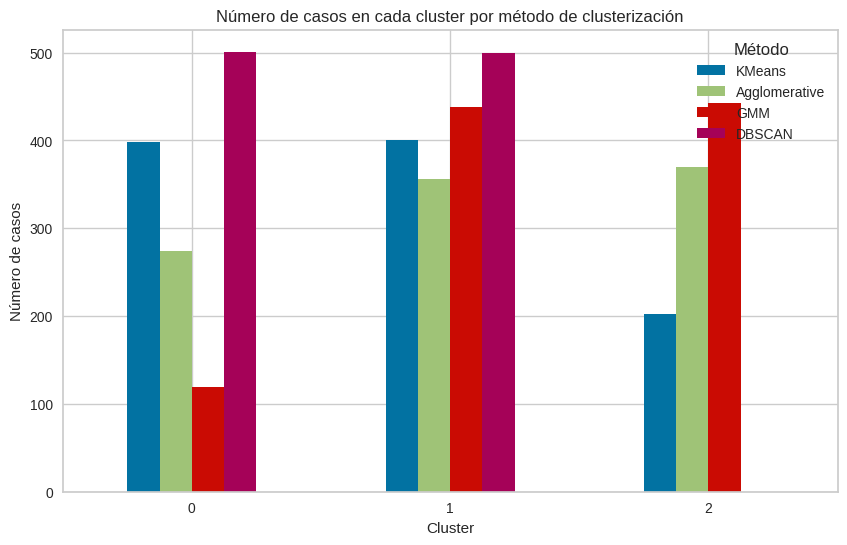

In [ ]:
# Calculando el número de casos en cada cluster para cada método
kmeans_counts = df_standard['kmeans_clusters'].value_counts().sort_index()
agglo_counts = df_standard['agglomerative_clusters'].value_counts().sort_index()
gmm_counts = df_standard['gmm_clusters'].value_counts().sort_index()
dbscan_counts = df_standard['dbscan_clusters'].value_counts().sort_index()

# Creando un DataFrame con los resultados
cluster_counts = pd.DataFrame({
    'KMeans': kmeans_counts,
    'Agglomerative': agglo_counts,
    'GMM': gmm_counts ,
    'DBSCAN': dbscan_counts
})

# Mostrando el DataFrame
print(cluster_counts)

# Opción adicional: graficando los resultados para visualizar mejor
import matplotlib.pyplot as plt

cluster_counts.plot(kind='bar', figsize=(10, 6))
plt.title('Número de casos en cada cluster por método de clusterización')
plt.xlabel('Cluster')
plt.ylabel('Número de casos')
plt.xticks(rotation=0)
plt.legend(title='Método')
plt.show()

### **PERFILAMIENTO DE CLIENTES USANDO CADA ALGORITMO DE CLUSTERING**

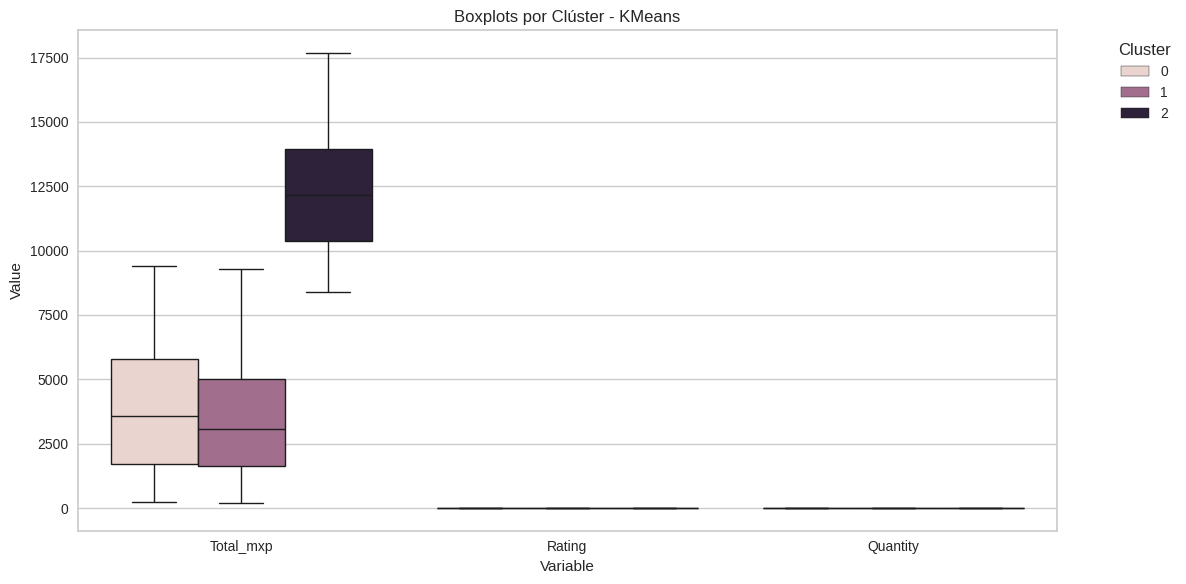

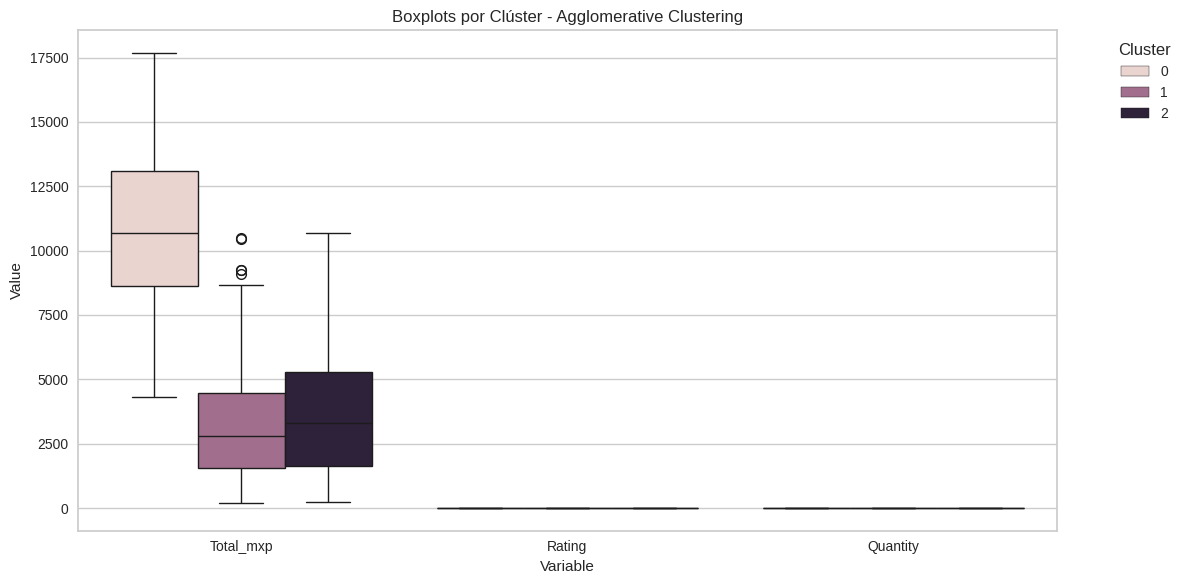

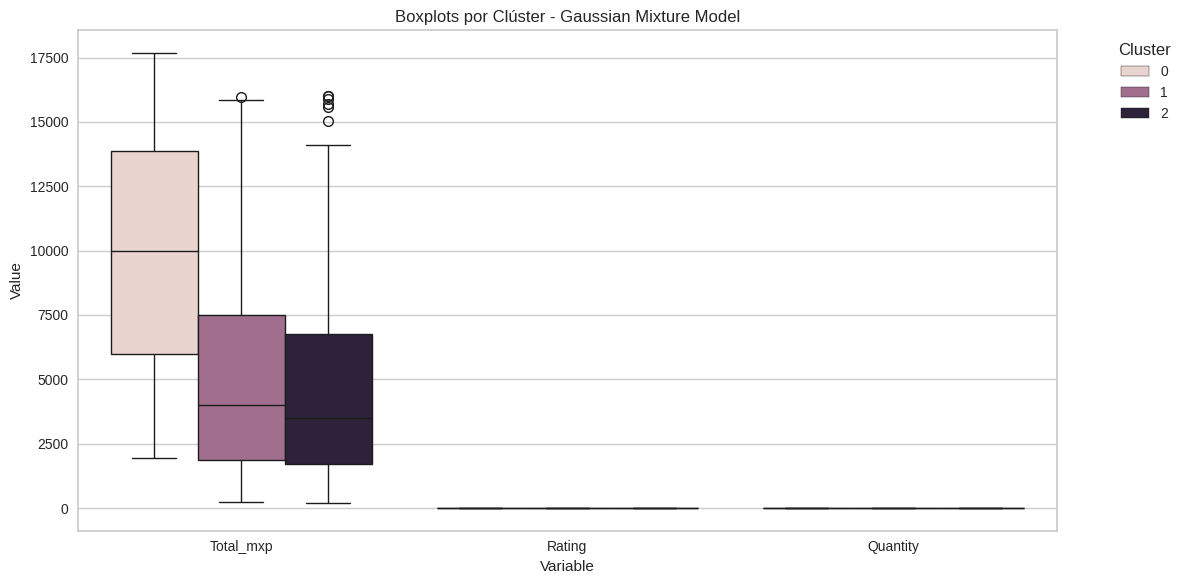

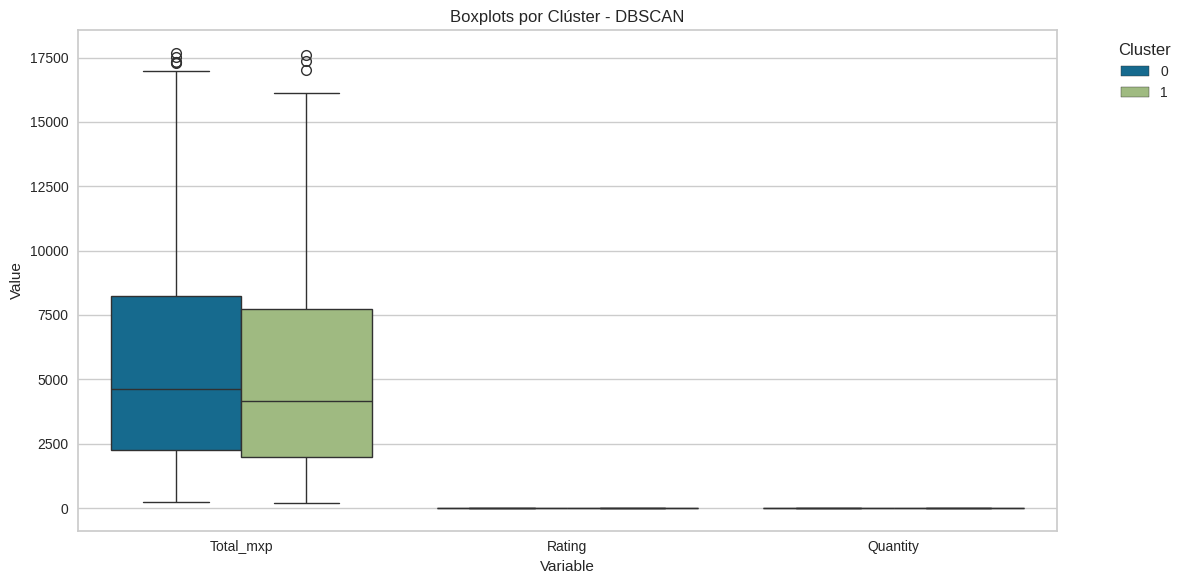

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


# Variables que deseamos considerar en la visualización
variables = ['Total_mxp', 'Rating', 'Quantity']

# Función para generar boxplots agrupados por clusters
def plot_cluster_boxplots(df, cluster_col, title):
    df_melted = df.melt(id_vars=[cluster_col], value_vars=variables,
                        var_name='Variable', value_name='Value')

    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df_melted, x='Variable', y='Value', hue=cluster_col)
    plt.title(title)
    plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Mosatrando los boxplots para cada algoritmo de clustering
plot_cluster_boxplots(df_encoded, 'kmeans_clusters', 'Boxplots por Clúster - KMeans')
plot_cluster_boxplots(df_encoded, 'agglomerative_clusters', 'Boxplots por Clúster - Agglomerative Clustering')
plot_cluster_boxplots(df_encoded, 'gmm_clusters', 'Boxplots por Clúster - Gaussian Mixture Model')
plot_cluster_boxplots(df_encoded, 'dbscan_clusters', 'Boxplots por Clúster - DBSCAN')

**Comentario:** Debido a la diferencia en la escala de las variables Rating y Quantity, no es posible visualizar correctamente sus box-plots cuando se grafican en conjunto. Por esta razón, se ejecutará la función de visualización por separado para cada variable, lo que permitirá una interpretación más clara y precisa.

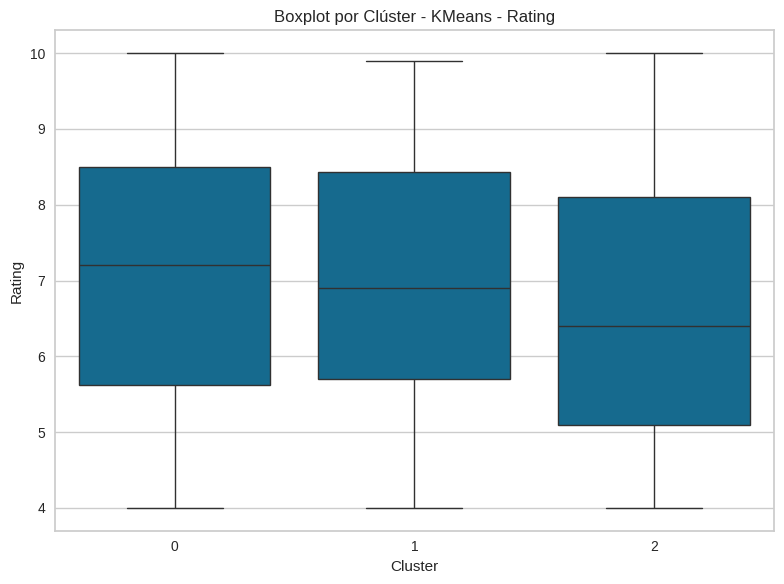

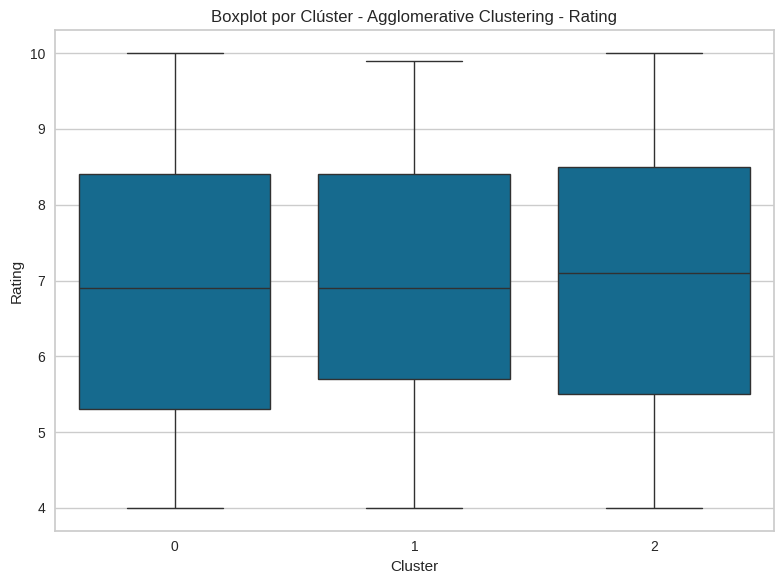

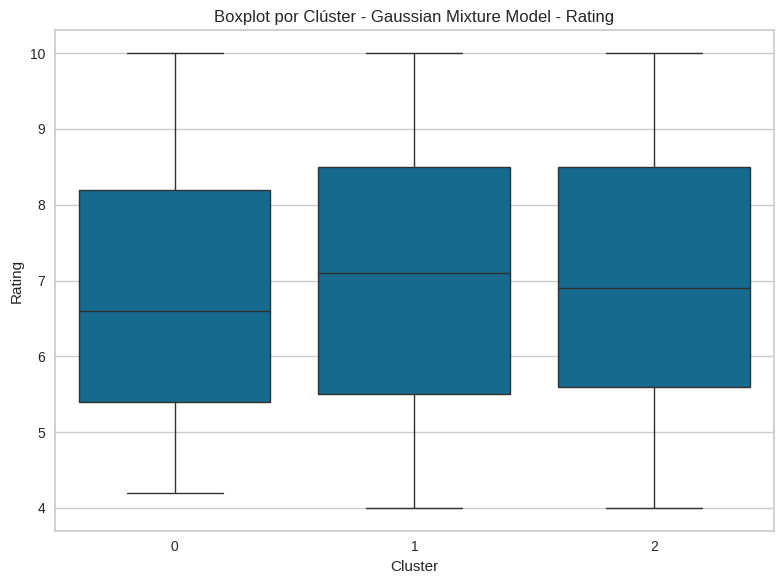

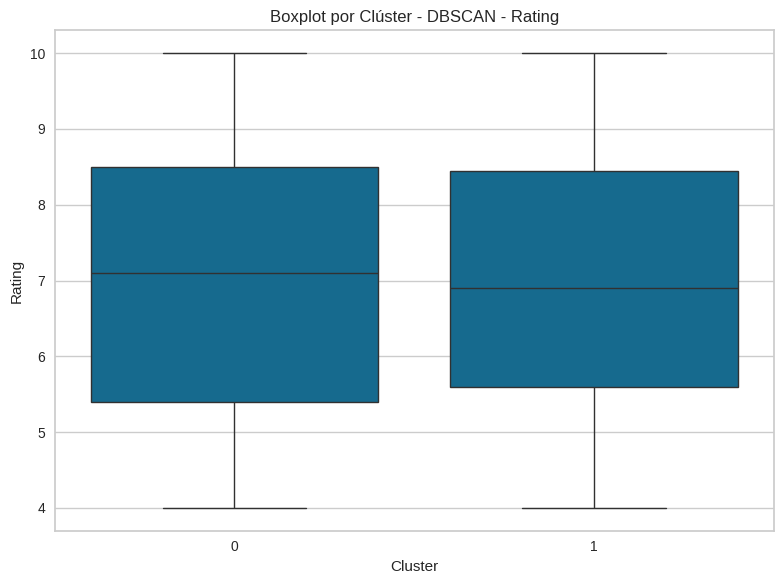

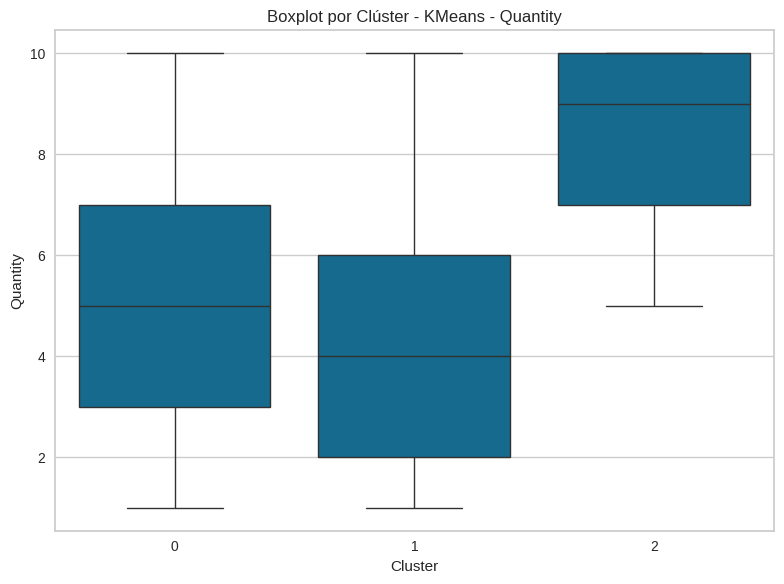

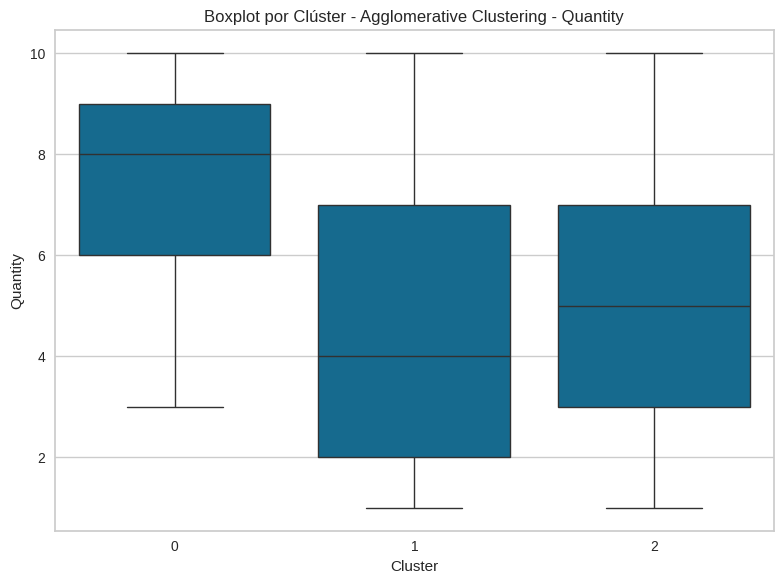

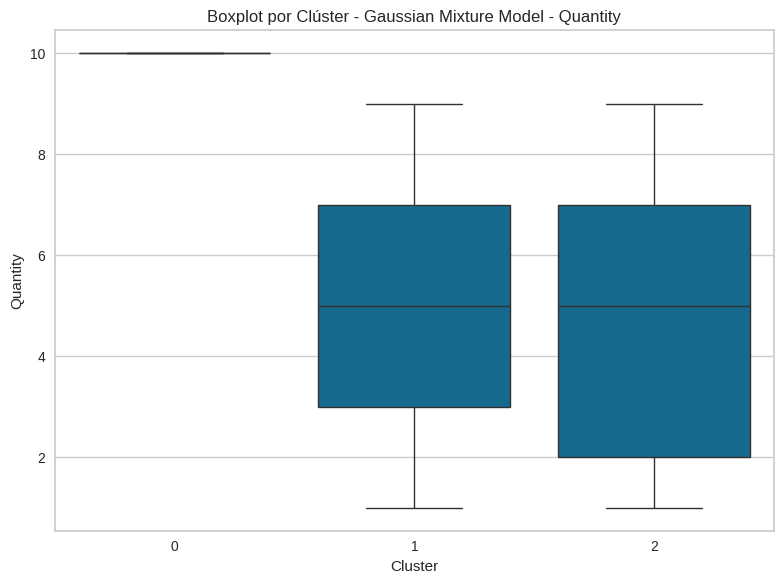

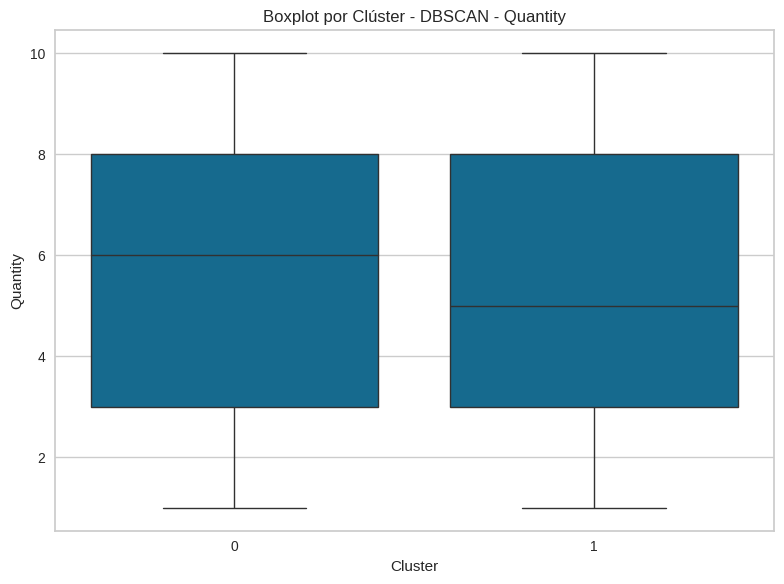

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Función para generar boxplots para una variable específica
def plot_variable_boxplot(df, cluster_col, variable, title):
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df, x=cluster_col, y=variable)
    plt.title(f'{title} - {variable}')
    plt.xlabel('Cluster')
    plt.ylabel(variable)
    plt.tight_layout()
    plt.show()

# Lista de variables a graficar
variables = ['Rating', 'Quantity']

# Algoritmos de clustering
cluster_algorithms = {
    'kmeans_clusters': 'KMeans',
    'agglomerative_clusters': 'Agglomerative Clustering',
    'gmm_clusters': 'Gaussian Mixture Model',
    'dbscan_clusters': 'DBSCAN'
}

# Generar boxplots por cada variable y cada algoritmo
for variable in variables:
    for cluster_col, method in cluster_algorithms.items():
        plot_variable_boxplot(df_encoded, cluster_col, variable, f'Boxplot por Clúster - {method}')


**Comentario:**

En el perfilamiento se identificó que tanto K-means como GMM consideran la variable Total_mxp como uno de los factores que mejor delimitan los grupos. Sin embargo, se observó que en GMM la distribución de los clústeres es más amplia, lo cual se refleja en un mayor tamaño de las cajas en los diagramas de caja; en contraste, en K-means los clústeres presentan una agrupación más compacta según su distribución.

En el análisis con K-means se identificaron tres clústeres diferenciados. El clúster 0 presenta un gasto que oscila entre 2,000 y 6,000 MXP, con una media aproximada de 3,500 MXP; el clúster 1 registra gastos entre 2,000 y 5,000 MXP, con una media de 3,000 MXP. En cuanto a la variable Rating, no se aprecian diferencias sustanciales entre los grupos, ya que las tres agrupaciones muestran una calificación media entre 6 y 7. Respecto a la cantidad de artículos adquiridos por transacción, el clúster 0 presenta una media de 5 artículos, el clúster 1 de 4 artículos y el clúster 2 de 9 artículos. Estos resultados sugieren que, aunque el gasto promedio y la calificación son relativamente homogéneos entre clústeres, **la cantidad de artículos comprados constituye una variable diferenciadora más marcada.**

**Recomendaciones finales:**

1. Cluster 0 – Gasto medio-alto con cantidad moderada de artículos
Perfil: Compra de 5 artículos en promedio, gasto cercano a 3 500 MXP, rating estable.

Recomendaciones:

* Implementar promociones por volumen moderado (ej. “lleva 6, paga 5”) para incentivar un ticket promedio ligeramente mayor.

* Mantener la experiencia de compra, ya que el rating es bueno y estable.

-------------------------------------------------------------------------

2. Cluster 1 – Gasto medio con menor cantidad de artículos
Perfil: Compra de 4 artículos en promedio, gasto cercano a 3 000 MXP.

Recomendaciones:

* Ofrecer bundles o combos que incentiven la compra de más artículos sin aumentar demasiado el gasto.

* Segmentar campañas con mensajes de “valor agregado” para aumentar el número de productos por compra.

--------------------------------------------------------------------------

3. Cluster 2 – Mayor cantidad de artículos por compra
Perfil: Compra de 9 artículos en promedio, gasto similar al resto, rating en rango estándar.

Recomendaciones:

Evaluar si este grupo aprovecha promociones agresivas o descuentos grandes; si es así, optimizar la rentabilidad ajustando el margen.

Potenciar programas de fidelidad que premien compras voluminosas (ej. puntos extra o envíos gratis).

Analizar si se trata de clientes mayoristas o revendedores y personalizar la oferta para este segmento.

--------------------------------------------------------------------------

**General:** La principal palanca para diferenciar estrategias entre clusters es el número de artículos por transacción.




## **FIN DEL NOTEBOOK**

In [ ]:
!jupyter nbconvert --execute --to html "/content/integrador_2_LFRG.ipynb"

[NbConvertApp] Converting notebook /content/integrador_2_LFRG.ipynb to html
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
[NbConvertApp] WARNING | Alternative text is missing on 34 image(s).
[NbConvertApp] Writing 3925002 bytes to /content/integrador_2_LFRG.html
